In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb

import kdar_functions as kdar
import general_functions as utils

from matplotlib.pyplot import cm

import importlib



In [2]:
single_run = True

In [3]:
importlib.reload(kdar)
importlib.reload(utils)

<module 'general_functions' from '/Users/bbogart/Documents/analysisCode/kdar_bdt/general_functions.py'>

In [4]:
model_hiE = xgb.Booster({'nthread': 4})  # init model
model_hiE.load_model('model_hiE_1.json')  # load data

model_lowE = xgb.Booster({'nthread': 4})  # init model
model_lowE.load_model('model_lowE_1.json')  # load data

model_hiE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_hiE_genie_only.load_model('model_hiE_genie_only_1.json')  # load data

model_lowE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_lowE_genie_only.load_model('model_lowE_genie_only_1.json')  # load data

lowE_cut = 0.8
hiE_cut = 0.9

bdt_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

bdt_query_genie = bdt_query #+" and event%10>=4"
bdt_query_nuwro = bdt_query +" and event%10>=5"
bdt_query_gibuu = bdt_query +" and event%10>=5"
bdt_query_lowE = bdt_query +" and event%10>=7"
bdt_query_hiE = bdt_query +" and event%10>=7"

In [113]:
def check_var(var,xmin,xmax,nbins,check_bckg=True,
              check_n_ppfx_uni=10,check_n_geom_uni=0,check_n_pip_uni=0,check_n_pim_uni=0,check_n_p_uni=0,
              check_bdtsel=False,check_presel=False,check_tagger=False,clipped=False,norm_sig=True,
              logy=False,xlabel_name="",multicolor=True,alpha=0.7):


        
    bins = np.linspace(xmin,xmax,nbins+1)
    err_truth = utils.get_x_err_Enu(utils.get_bin_centers(bins),bins)

    clipped_max =  99999999
    clipped_min = -99999999
    if clipped:
        clipped_max = xmax
        clipped_min = xmin       
    
    query = "is_KDAR==1"
    if check_bckg:
        norm_sig=False
        query = "is_KDAR==0"
        
    if check_bdtsel and check_bckg: query = query+" and " + bdt_query_hiE
    elif check_bdtsel: query = query+" and " + bdt_query_genie
    elif check_presel: query = query+" and " + kdar.presel_query
    elif check_tagger: query = query+" and ssm_kine_energy>0"

    if check_bckg:
        if check_n_ppfx_uni>599: check_n_ppfx_uni=599
        color = iter(cm.rainbow(np.linspace(0, 1, check_n_ppfx_uni)))
        if check_n_ppfx_uni>0:
            check_n_geom_uni=0
            check_n_pip_uni=0
            check_n_pim_uni=0
            check_n_p_uni=0
    
            temp_df = overlay_df_kminus_PrimaryHadronNormalization.query(query)
            
            sig_test, _xx = np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                                            bins=bins,density=False,
                                            weights=temp_df['net_weight'].to_numpy())
            if norm_sig == True: 
                norm_sig_test = np.sum(sig_test)
                sig_test = sig_test/norm_sig_test
            max_y = np.max(sig_test)
            
            plt.figure()
            plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')
        
            if multicolor: c = next(color)
            else: c = 'dodgerblue'
            var_name = f"kminus_PrimaryHadronNormalization0"
            y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                     bins=nbins, range=(xmin,xmax),
                     weights=temp_df[var_name]*temp_df["net_weight"].to_numpy(),         
            )   
    
            if norm_sig: 
                norm_y = np.sum(y)
                y = y/norm_y   
            max_y = np.max([max_y,np.max(y)])
            plt.stairs(y,edges=bins,alpha=alpha,color=c,label='PPFX Multisim')
        if check_n_ppfx_uni>1:  
            for uni in range(1,check_n_ppfx_uni):
                if multicolor: c = next(color)
                else: c = 'dodgerblue'
                var_name = f"kminus_PrimaryHadronNormalization{uni}"
                y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                         bins=nbins, range=(xmin,xmax),
                         weights=temp_df[var_name]*temp_df["net_weight"].to_numpy()
                )
                if norm_sig: 
                    norm_y = np.sum(y)
                    y = y/norm_y        
                max_y = np.max([max_y,np.max(y)])
                plt.stairs(y,edges=bins,alpha=alpha,color=c)
    
    
    
        if check_n_geom_uni>599: check_n_geom_uni=599
        color = iter(cm.rainbow(np.linspace(0, 1, check_n_geom_uni)))
        if check_n_geom_uni>0:
            check_n_pip_uni=0
            check_n_pim_uni=0
            check_n_p_uni=0
    
            temp_df = overlay_df_geom.query(query)
            
            sig_test, _xx = np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                                            bins=bins,density=False,
                                            weights=temp_df['net_weight'].to_numpy())
            if norm_sig == True: 
                norm_sig_test = np.sum(sig_test)
                sig_test = sig_test/norm_sig_test
            max_y = np.max(sig_test)
            
            plt.figure()
            plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')
            
            if multicolor: c = next(color)
            else: c = 'dodgerblue'
            var_name = f"geom0"
            y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                     bins=nbins, range=(xmin,xmax),
                     weights=temp_df[var_name]*temp_df["net_weight"].to_numpy(),         
            )   
    
            if norm_sig: 
                norm_y = np.sum(y)
                y = y/norm_y   
            max_y = np.max([max_y,np.max(y)])
            plt.stairs(y,edges=bins,alpha=alpha,color=c,label='Geom Multisim')
        if check_n_geom_uni>1:  
            for uni in range(1,check_n_geom_uni):
                if multicolor: c = next(color)
                else: c = 'dodgerblue'
                var_name = f"geom{uni}"
                y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                         bins=nbins, range=(xmin,xmax),
                         weights=temp_df[var_name]*temp_df["net_weight"].to_numpy()
                )
                if norm_sig: 
                    norm_y = np.sum(y)
                    y = y/norm_y        
                max_y = np.max([max_y,np.max(y)])
                plt.stairs(y,edges=bins,alpha=alpha,color=c)
            
    
        if check_n_pip_uni>599: check_n_pip_uni=599
        color = iter(cm.rainbow(np.linspace(0, 1, check_n_pip_uni)))
        if check_n_pip_uni>0:
            check_n_pim_uni=0
            check_n_p_uni=0
    
            temp_df = overlay_df_reinteractions_piplus_Geant4.query(query)
            
            sig_test, _xx = np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                                            bins=bins,density=False,
                                            weights=temp_df['net_weight'].to_numpy())
            if norm_sig == True: 
                norm_sig_test = np.sum(sig_test)
                sig_test = sig_test/norm_sig_test
            max_y = np.max(sig_test)
            
            plt.figure()
            plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')
        
            if multicolor: c = next(color)
            else: c = 'dodgerblue'
            var_name = f"reinteractions_piplus_Geant40"
            y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                     bins=nbins, range=(xmin,xmax),
                     weights=temp_df[var_name]*temp_df["net_weight"].to_numpy(),         
            )   
    
            if norm_sig: 
                norm_y = np.sum(y)
                y = y/norm_y   
            max_y = np.max([max_y,np.max(y)])
            plt.stairs(y,edges=bins,alpha=alpha,color=c,label='G4 piplus Multisim')
        if check_n_pip_uni>1:  
            for uni in range(1,check_n_pip_uni):
                if multicolor: c = next(color)
                else: c = 'dodgerblue'
                var_name = f"reinteractions_piplus_Geant4{uni}"
                y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                         bins=nbins, range=(xmin,xmax),
                         weights=temp_df[var_name]*temp_df["net_weight"].to_numpy()
                )
                if norm_sig: 
                    norm_y = np.sum(y)
                    y = y/norm_y        
                max_y = np.max([max_y,np.max(y)])
                plt.stairs(y,edges=bins,alpha=alpha,color=c)
    
    
    
        
        if check_n_p_uni>599: check_n_p_uni=599
        color = iter(cm.rainbow(np.linspace(0, 1, check_n_p_uni)))
        if check_n_p_uni>0:
            check_n_pim_uni=0
    
            temp_df = overlay_df_reinteractions_proton_Geant4.query(query)
            
            sig_test, _xx = np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                                            bins=bins,density=False,
                                            weights=temp_df['net_weight'].to_numpy())
            if norm_sig == True: 
                norm_sig_test = np.sum(sig_test)
                sig_test = sig_test/norm_sig_test
            max_y = np.max(sig_test)
            
            plt.figure()
            plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')
        
            if multicolor: c = next(color)
            else: c = 'dodgerblue'
            var_name = f"reinteractions_proton_Geant40"
            y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                     bins=nbins, range=(xmin,xmax),
                     weights=temp_df[var_name]*temp_df["net_weight"].to_numpy(),         
            )   
    
            if norm_sig: 
                norm_y = np.sum(y)
                y = y/norm_y   
            max_y = np.max([max_y,np.max(y)])
            plt.stairs(y,edges=bins,alpha=alpha,color=c,label='G4 Proton Multisim')
        if check_n_p_uni>1:  
            for uni in range(1,check_n_p_uni):
                if multicolor: c = next(color)
                else: c = 'dodgerblue'
                var_name = f"reinteractions_proton_Geant4{uni}"
                y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                         bins=nbins, range=(xmin,xmax),
                         weights=temp_df[var_name]*temp_df["net_weight"].to_numpy()
                )
                if norm_sig: 
                    norm_y = np.sum(y)
                    y = y/norm_y        
                max_y = np.max([max_y,np.max(y)])
                plt.stairs(y,edges=bins,alpha=alpha,color=c)



    else:
        if check_n_p_uni>599: check_n_p_uni=599
        color = iter(cm.rainbow(np.linspace(0, 1, check_n_p_uni)))
        if check_n_p_uni>0:
            check_n_pim_uni=0
    
            temp_df = kdar_overlay_df.query(query)
            
            sig_test, _xx = np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                                            bins=bins,density=False,
                                            weights=temp_df['net_weight'].to_numpy())
            if norm_sig == True: 
                norm_sig_test = np.sum(sig_test)
                sig_test = sig_test/norm_sig_test
            max_y = np.max(sig_test)
            
            plt.figure()
            plt.errorbar(utils.get_bin_centers(bins),sig_test,label='CV', ms=5, fmt='o',lw=4,color='black')
        
            if multicolor: c = next(color)
            else: c = 'dodgerblue'
            var_name = f"reinteractions_proton_Geant40"
            y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                     bins=nbins, range=(xmin,xmax),
                     weights=temp_df[var_name]*temp_df["net_weight"].to_numpy(),         
            )   
    
            if norm_sig: 
                norm_y = np.sum(y)
                y = y/norm_y   
            max_y = np.max([max_y,np.max(y)])
            plt.stairs(y,edges=bins,alpha=alpha,color=c,label='G4 Proton Multisim')
        if check_n_p_uni>1:  
            for uni in range(1,check_n_p_uni):
                if multicolor: c = next(color)
                else: c = 'dodgerblue'
                var_name = f"reinteractions_proton_Geant4{uni}"
                y,x=np.histogram(np.clip(temp_df[var].to_numpy(),clipped_min,clipped_max),
                         bins=nbins, range=(xmin,xmax),
                         weights=temp_df[var_name]*temp_df["net_weight"].to_numpy()
                )
                if norm_sig: 
                    norm_y = np.sum(y)
                    y = y/norm_y        
                max_y = np.max([max_y,np.max(y)])
                plt.stairs(y,edges=bins,alpha=alpha,color=c)



    plt.xlabel(var)
    if xlabel_name!="": plt.xlabel(xlabel_name)
    if norm_sig: plt.ylabel("Normalized Counts")
    else: plt.ylabel("Events")
    title_suffix = 'Signal'
    if check_bckg: title_suffix = 'Bckground'
    plt.legend(title=title_suffix)
    if check_bdtsel: plt.legend(title='BDT Selected '+title_suffix)
    elif check_presel: plt.legend(title='Preselected '+title_suffix)
    elif check_tagger: plt.legend(title='Tagged '+title_suffix)
    plt.ylim(0,1.1*max_y)
    if logy: plt.yscale("log")
    plt.show()



In [271]:
weight_vars = ['mcweight_filled','reinteractions_proton_Geant4']

f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_UseGroundStateRemnant_kdar_overlay_run4b_reinteractions_proton_Geant4.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_kdar_overlay_weight = f_kdar_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
kdar_overlay_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine,f_kdar_overlay_weight], axis=1, sort=False)

kdar_overlay_df["horncur"] = ["RHC" for i in range(kdar_overlay_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run1_train_reinteractions_proton_Geant4.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_kdar_overlay_weight = f_kdar_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
    f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
    kdar_overlay_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine,f_kdar_overlay_weight], axis=1, sort=False)

    kdar_overlay_df_2["horncur"] = ["FHC" for i in range(kdar_overlay_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    kdar_overlay_df = pd.concat([kdar_overlay_df, kdar_overlay_df_2], sort=False)

kdar_overlay_df = kdar.apply_goodruns(kdar_overlay_df)

kdar_overlay_df["net_weight"] = kdar_overlay_df["weight_cv"].to_numpy()*kdar_overlay_df["weight_spline"].to_numpy()
print("All events",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["rse_num"] = (kdar_overlay_df["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df["event"].to_numpy())
kdar_overlay_df = kdar_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df = kdar_overlay_df.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["isEXT"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["isDirt"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["POTscaled"] = [1 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["is_KDAR"] = [1 for i in range(kdar_overlay_df.shape[0])]


All events 50388 50781.67
Duplicates Dropped 50388 50781.67
In FV 50119 50528.223


In [ ]:

print("All",kdar_overlay_df.shape[0])
kdar_overlay_df = kdar_overlay_df.query('mcweight_filled==1')
print("mcweight_filled==1",kdar_overlay_df.shape[0])

reinteractions_proton_Geant4 = kdar_overlay_df["reinteractions_proton_Geant4"].to_numpy()
for uni in range(20):
    reinteractions_proton_Geant4_temp = []
    var_name = f"reinteractions_proton_Geant4{uni}"
    print(var_name)
    for i in range(len(reinteractions_proton_Geant4)):
        reinteractions_proton_Geant4_temp.append(np.clip(np.nan_to_num(reinteractions_proton_Geant4[i][uni],nan=0),0,30))
    kdar_overlay_df[var_name] = reinteractions_proton_Geant4_temp



In [6]:
weight_vars = ['mcweight_filled','kminus_PrimaryHadronNormalization']


f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_oldflux_overlay_run4b_rhc_train_kminus_PrimaryHadronNormalization.root")["wcpselection"]
f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
overlay_df = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

overlay_df["horncur"] = ["RHC" for i in range(overlay_df.shape[0])]

del f_overlay
del f_overlay_bdt
del f_overlay_eval
del f_overlay_pfeval
del f_overlay_kine

if not single_run: 
    f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run1_fhc_train_kminus_PrimaryHadronNormalization.root")["wcpselection"]
    f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
    overlay_df_2 = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

    overlay_df_2["horncur"] = ["FHC" for i in range(overlay_df_2.shape[0])]
    
    del f_overlay
    del f_overlay_bdt
    del f_overlay_eval
    del f_overlay_pfeval
    del f_overlay_kine

    overlay_df = pd.concat([overlay_df, overlay_df_2], sort=False)

overlay_df = kdar.apply_goodruns(overlay_df)

overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
print("All events",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

#overlay_df = overlay_df.query("truth_vtxInside==1")
#print("In FV",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["isEXT"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["isDirt"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["WC_file"] = ["numi_overlay" for i in range(overlay_df.shape[0])]
overlay_df["POTscaled"] = [1 for i in range(overlay_df.shape[0])]

overlay_df_kminus_PrimaryHadronNormalization = overlay_df


All events 268824 193205.5
Duplicates Dropped 268824 193205.5


In [8]:

print("All",overlay_df_kminus_PrimaryHadronNormalization.shape[0])
overlay_df_kminus_PrimaryHadronNormalization = overlay_df_kminus_PrimaryHadronNormalization.query('mcweight_filled==1')
print("mcweight_filled==1",overlay_df_kminus_PrimaryHadronNormalization.shape[0])

kminus_PrimaryHadronNormalization = overlay_df_kminus_PrimaryHadronNormalization["kminus_PrimaryHadronNormalization"].to_numpy()
for uni in range(20):
    kminus_PrimaryHadronNormalization_temp = []
    var_name = f"kminus_PrimaryHadronNormalization{uni}"
    print(var_name)
    for i in range(len(kminus_PrimaryHadronNormalization)):
        kminus_PrimaryHadronNormalization_temp.append(np.clip(np.nan_to_num(kminus_PrimaryHadronNormalization[i][uni],nan=0),0,30))
    overlay_df_kminus_PrimaryHadronNormalization[var_name] = kminus_PrimaryHadronNormalization_temp



All 268824
mcweight_filled==1 268824
kminus_PrimaryHadronNormalization0
kminus_PrimaryHadronNormalization1
kminus_PrimaryHadronNormalization2
kminus_PrimaryHadronNormalization3
kminus_PrimaryHadronNormalization4
kminus_PrimaryHadronNormalization5
kminus_PrimaryHadronNormalization6
kminus_PrimaryHadronNormalization7
kminus_PrimaryHadronNormalization8
kminus_PrimaryHadronNormalization9
kminus_PrimaryHadronNormalization10
kminus_PrimaryHadronNormalization11
kminus_PrimaryHadronNormalization12
kminus_PrimaryHadronNormalization13
kminus_PrimaryHadronNormalization14
kminus_PrimaryHadronNormalization15
kminus_PrimaryHadronNormalization16
kminus_PrimaryHadronNormalization17
kminus_PrimaryHadronNormalization18
kminus_PrimaryHadronNormalization19


In [10]:
weight_vars = ['mcweight_filled','nucleoninexsec_FluxUnisim']


f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_oldflux_overlay_run4b_rhc_train_geom.root")["wcpselection"]
f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
overlay_df = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

overlay_df["horncur"] = ["RHC" for i in range(overlay_df.shape[0])]

del f_overlay
del f_overlay_bdt
del f_overlay_eval
del f_overlay_pfeval
del f_overlay_kine

if not single_run: 
    f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run1_fhc_train_geom.root")["wcpselection"]
    f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
    overlay_df_2 = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

    overlay_df_2["horncur"] = ["FHC" for i in range(overlay_df_2.shape[0])]
    
    del f_overlay
    del f_overlay_bdt
    del f_overlay_eval
    del f_overlay_pfeval
    del f_overlay_kine

    overlay_df = pd.concat([overlay_df, overlay_df_2], sort=False)

overlay_df = kdar.apply_goodruns(overlay_df)

overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
print("All events",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

#overlay_df = overlay_df.query("truth_vtxInside==1")
#print("In FV",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["isEXT"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["isDirt"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["WC_file"] = ["numi_overlay" for i in range(overlay_df.shape[0])]
overlay_df["POTscaled"] = [1 for i in range(overlay_df.shape[0])]

overlay_df_geom = overlay_df


All events 602962 437149.1
Duplicates Dropped 602962 437149.1


In [11]:
print("All",overlay_df_geom.shape[0])
overlay_df_geom = overlay_df_geom.query('mcweight_filled==1')
print("mcweight_filled==1",overlay_df_geom.shape[0])

nucleoninexsec_FluxUnisim = overlay_df_geom["nucleoninexsec_FluxUnisim"].to_numpy()
for uni in range(20):
    nucleoninexsec_FluxUnisim_temp = []
    var_name = f"geom{uni}"
    print(var_name)
    for i in range(len(nucleoninexsec_FluxUnisim)):
        nucleoninexsec_FluxUnisim_temp.append(np.clip(np.nan_to_num(nucleoninexsec_FluxUnisim[i][uni],nan=0),0,30))
    overlay_df_geom[var_name] = nucleoninexsec_FluxUnisim_temp

All 602962
mcweight_filled==1 602962
geom0
geom1
geom2
geom3
geom4
geom5
geom6
geom7
geom8
geom9
geom10
geom11
geom12
geom13
geom14
geom15
geom16
geom17
geom18
geom19


In [24]:
weight_vars = ['mcweight_filled','reinteractions_piplus_Geant4']


f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_oldflux_overlay_run4b_rhc_train_reinteractions_piplus_Geant4.root")["wcpselection"]
f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
overlay_df = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

overlay_df["horncur"] = ["RHC" for i in range(overlay_df.shape[0])]

del f_overlay
del f_overlay_bdt
del f_overlay_eval
del f_overlay_pfeval
del f_overlay_kine

if not single_run: 
    f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run1_fhc_train_reinteractions_piplus_Geant4.root")["wcpselection"]
    f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
    overlay_df_2 = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

    overlay_df_2["horncur"] = ["FHC" for i in range(overlay_df_2.shape[0])]
    
    del f_overlay
    del f_overlay_bdt
    del f_overlay_eval
    del f_overlay_pfeval
    del f_overlay_kine

    overlay_df = pd.concat([overlay_df, overlay_df_2], sort=False)

overlay_df = kdar.apply_goodruns(overlay_df)

overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
print("All events",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

#overlay_df = overlay_df.query("truth_vtxInside==1")
#print("In FV",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["isEXT"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["isDirt"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["WC_file"] = ["numi_overlay" for i in range(overlay_df.shape[0])]
overlay_df["POTscaled"] = [1 for i in range(overlay_df.shape[0])]

overlay_df_reinteractions_piplus_Geant4 = overlay_df


All events 268824 193205.5
Duplicates Dropped 268824 193205.5


In [25]:
print("All",overlay_df_reinteractions_piplus_Geant4.shape[0])
overlay_df_reinteractions_piplus_Geant4 = overlay_df_reinteractions_piplus_Geant4.query('mcweight_filled==1')
print("mcweight_filled==1",overlay_df_reinteractions_piplus_Geant4.shape[0])

reinteractions_piplus_Geant4 = overlay_df_reinteractions_piplus_Geant4["reinteractions_piplus_Geant4"].to_numpy()
for uni in range(20):
    reinteractions_piplus_Geant4_temp = []
    var_name = f"reinteractions_piplus_Geant4{uni}"
    print(var_name)
    for i in range(len(reinteractions_piplus_Geant4)):
        reinteractions_piplus_Geant4_temp.append(np.clip(np.nan_to_num(reinteractions_piplus_Geant4[i][uni],nan=0),0,30))
    overlay_df_reinteractions_piplus_Geant4[var_name] = reinteractions_piplus_Geant4_temp


All 268824
mcweight_filled==1 268824
reinteractions_piplus_Geant40
reinteractions_piplus_Geant41
reinteractions_piplus_Geant42
reinteractions_piplus_Geant43
reinteractions_piplus_Geant44
reinteractions_piplus_Geant45
reinteractions_piplus_Geant46
reinteractions_piplus_Geant47
reinteractions_piplus_Geant48
reinteractions_piplus_Geant49
reinteractions_piplus_Geant410
reinteractions_piplus_Geant411
reinteractions_piplus_Geant412
reinteractions_piplus_Geant413
reinteractions_piplus_Geant414
reinteractions_piplus_Geant415
reinteractions_piplus_Geant416
reinteractions_piplus_Geant417
reinteractions_piplus_Geant418
reinteractions_piplus_Geant419


In [26]:
weight_vars = ['mcweight_filled','reinteractions_proton_Geant4']


f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/sys/prodgenie_oldflux_overlay_run4b_rhc_train_reinteractions_proton_Geant4.root")["wcpselection"]
f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
overlay_df = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

overlay_df["horncur"] = ["RHC" for i in range(overlay_df.shape[0])]

del f_overlay
del f_overlay_bdt
del f_overlay_eval
del f_overlay_pfeval
del f_overlay_kine

if not single_run: 
    f_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_oldflux_overlay_run1_fhc_train_reinteractions_proton_Geant4.root")["wcpselection"]
    f_overlay_bdt = f_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_overlay_eval = f_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_overlay_pfeval = f_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_overlay_kine = f_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_overlay_weight = f_overlay["T_weight"].pandas.df(weight_vars, flatten=False)
    overlay_df_2 = pd.concat([f_overlay_bdt, f_overlay_eval, f_overlay_pfeval, f_overlay_kine,f_overlay_weight], axis=1, sort=False)

    overlay_df_2["horncur"] = ["FHC" for i in range(overlay_df_2.shape[0])]
    
    del f_overlay
    del f_overlay_bdt
    del f_overlay_eval
    del f_overlay_pfeval
    del f_overlay_kine

    overlay_df = pd.concat([overlay_df, overlay_df_2], sort=False)

overlay_df = kdar.apply_goodruns(overlay_df)

overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
print("All events",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

#overlay_df = overlay_df.query("truth_vtxInside==1")
#print("In FV",overlay_df.shape[0],np.sum(overlay_df["net_weight"].to_numpy()))

overlay_df["isEXT"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["isDirt"] = [0 for i in range(overlay_df.shape[0])]
overlay_df["WC_file"] = ["numi_overlay" for i in range(overlay_df.shape[0])]
overlay_df["POTscaled"] = [1 for i in range(overlay_df.shape[0])]

overlay_df_reinteractions_proton_Geant4 = overlay_df


All events 268824 193205.5
Duplicates Dropped 268824 193205.5


In [27]:

print("All",overlay_df_reinteractions_proton_Geant4.shape[0])
overlay_df_reinteractions_proton_Geant4 = overlay_df_reinteractions_proton_Geant4.query('mcweight_filled==1')
print("mcweight_filled==1",overlay_df_reinteractions_proton_Geant4.shape[0])

reinteractions_proton_Geant4 = overlay_df_reinteractions_proton_Geant4["reinteractions_proton_Geant4"].to_numpy()
for uni in range(20):
    reinteractions_proton_Geant4_temp = []
    var_name = f"reinteractions_proton_Geant4{uni}"
    print(var_name)
    for i in range(len(reinteractions_proton_Geant4)):
        reinteractions_proton_Geant4_temp.append(np.clip(np.nan_to_num(reinteractions_proton_Geant4[i][uni],nan=0),0,30))
    overlay_df_reinteractions_proton_Geant4[var_name] = reinteractions_proton_Geant4_temp



All 268824
mcweight_filled==1 268824
reinteractions_proton_Geant40
reinteractions_proton_Geant41
reinteractions_proton_Geant42
reinteractions_proton_Geant43
reinteractions_proton_Geant44
reinteractions_proton_Geant45
reinteractions_proton_Geant46
reinteractions_proton_Geant47
reinteractions_proton_Geant48
reinteractions_proton_Geant49
reinteractions_proton_Geant410
reinteractions_proton_Geant411
reinteractions_proton_Geant412
reinteractions_proton_Geant413
reinteractions_proton_Geant414
reinteractions_proton_Geant415
reinteractions_proton_Geant416
reinteractions_proton_Geant417
reinteractions_proton_Geant418
reinteractions_proton_Geant419


In [32]:

#kdar_overlay_df = kdar.add_ntrue_nu_angle(kdar_overlay_df)
#kdar_overlay_df = kdar.add_truth_muon_info(kdar_overlay_df)
#kdar_overlay_df = kdar.add_truth_proton_info(kdar_overlay_df)
#kdar_overlay_df = kdar.add_truth_ssm_info(kdar_overlay_df)

overlay_df_kminus_PrimaryHadronNormalization = kdar.add_ntrue_nu_angle(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_truth_muon_info(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_truth_proton_info(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_truth_ssm_info(overlay_df_kminus_PrimaryHadronNormalization)

overlay_df_geom = kdar.add_ntrue_nu_angle(overlay_df_geom)
overlay_df_geom = kdar.add_truth_muon_info(overlay_df_geom)
overlay_df_geom = kdar.add_truth_proton_info(overlay_df_geom)
overlay_df_geom = kdar.add_truth_ssm_info(overlay_df_geom)

overlay_df_reinteractions_piplus_Geant4 = kdar.add_ntrue_nu_angle(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_truth_muon_info(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_truth_proton_info(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_truth_ssm_info(overlay_df_reinteractions_piplus_Geant4)

overlay_df_reinteractions_proton_Geant4 = kdar.add_ntrue_nu_angle(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_truth_muon_info(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_truth_proton_info(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_truth_ssm_info(overlay_df_reinteractions_proton_Geant4)


  0%|                                                | 0/268550 [00:00<?, ?it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1442: RuntimeWarning: invalid value encountered in sqrt
  true_W.append( np.sqrt(938*938 + 2*938*true_nu[-1] - true_Q2[-1]) )
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1436: RuntimeWarning: invalid value encountered in sqrt
  true_sqrtQ2.append( np.sqrt(2*235.5*(Emu[event]-k[event]*cos)-105.7*105.7 ))
  0%|                                                | 0/268824 [00:00<?, ?it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1442: RuntimeWarning: invalid value encountered in sqrt
  true_W.append( np.sqrt(938*938 + 2*938*true_nu[-1] - true_Q2[-1]) )
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1436: RuntimeWarning: invalid value encountered in sqrt
  true_sqrtQ2.append( np.sqrt(2*235.5*(Emu[event]-k[event]*cos)-105.7*105.7 ))
100%|████████████████████████████████| 268824/268824 [00:0

In [14]:
print("Total",overlay_df_kminus_PrimaryHadronNormalization.shape[0],np.sum(overlay_df_kminus_PrimaryHadronNormalization["net_weight"].to_numpy()))
overlay_df_kminus_PrimaryHadronNormalization = kdar.set_is_kdar(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = overlay_df_kminus_PrimaryHadronNormalization.query("is_KDAR==0")
print("No KDARs",overlay_df_kminus_PrimaryHadronNormalization.shape[0],np.sum(overlay_df_kminus_PrimaryHadronNormalization["net_weight"].to_numpy()))

Total 268824 193205.5


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1523: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_KDAR"] = is_KDAR


No KDARs 268550 192650.81


In [15]:
print("Total",overlay_df_geom.shape[0],np.sum(overlay_df_geom["net_weight"].to_numpy()))
overlay_df_geom = kdar.set_is_kdar(overlay_df_geom)
overlay_df_geom = overlay_df_geom.query("is_KDAR==0")
print("No KDARs",overlay_df_geom.shape[0],np.sum(overlay_df_geom["net_weight"].to_numpy()))

Total 602962 437149.1


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1523: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_KDAR"] = is_KDAR


No KDARs 602682 436587.3


In [30]:
print("Total",overlay_df_reinteractions_piplus_Geant4.shape[0],np.sum(overlay_df_reinteractions_piplus_Geant4["net_weight"].to_numpy()))
overlay_df_reinteractions_piplus_Geant4 = kdar.set_is_kdar(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = overlay_df_reinteractions_piplus_Geant4.query("is_KDAR==0")
print("No KDARs",overlay_df_reinteractions_piplus_Geant4.shape[0],np.sum(overlay_df_reinteractions_piplus_Geant4["net_weight"].to_numpy()))

Total 268824 193205.5


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1523: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_KDAR"] = is_KDAR


No KDARs 268550 192650.81


In [33]:
print("Total",overlay_df_reinteractions_proton_Geant4.shape[0],np.sum(overlay_df_reinteractions_proton_Geant4["net_weight"].to_numpy()))
overlay_df_reinteractions_proton_Geant4 = kdar.set_is_kdar(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = overlay_df_reinteractions_proton_Geant4.query("is_KDAR==0")
print("No KDARs",overlay_df_reinteractions_proton_Geant4.shape[0],np.sum(overlay_df_reinteractions_proton_Geant4["net_weight"].to_numpy()))

Total 268824 193205.5


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1523: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_KDAR"] = is_KDAR


No KDARs 268550 192650.81


In [34]:

#kdar_overlay_df = kdar.add_ssm_kine_info(kdar_overlay_df)
#kdar_overlay_df = kdar.add_ssm_reco_proton_info(kdar_overlay_df)
#kdar_overlay_df = kdar.add_reco_proton_muon(kdar_overlay_df)
#kdar_overlay_df = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df)

overlay_df_kminus_PrimaryHadronNormalization = kdar.add_ssm_kine_info(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_ssm_reco_proton_info(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_reco_proton_muon(overlay_df_kminus_PrimaryHadronNormalization)
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_ssm_reco_dirt_vars(overlay_df_kminus_PrimaryHadronNormalization)

overlay_df_geom = kdar.add_ssm_kine_info(overlay_df_geom)
overlay_df_geom = kdar.add_ssm_reco_proton_info(overlay_df_geom)
overlay_df_geom = kdar.add_reco_proton_muon(overlay_df_geom)
overlay_df_geom = kdar.add_ssm_reco_dirt_vars(overlay_df_geom)

overlay_df_reinteractions_piplus_Geant4 = kdar.add_ssm_kine_info(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_ssm_reco_proton_info(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_reco_proton_muon(overlay_df_reinteractions_piplus_Geant4)
overlay_df_reinteractions_piplus_Geant4 = kdar.add_ssm_reco_dirt_vars(overlay_df_reinteractions_piplus_Geant4)

overlay_df_reinteractions_proton_Geant4 = kdar.add_ssm_kine_info(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_ssm_reco_proton_info(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_reco_proton_muon(overlay_df_reinteractions_proton_Geant4)
overlay_df_reinteractions_proton_Geant4 = kdar.add_ssm_reco_dirt_vars(overlay_df_reinteractions_proton_Geant4)


100%|███████████████████████████████| 268550/268550 [00:02<00:00, 124608.44it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1587: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_q"] = ssm_q
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1588: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ssm_Q2"] = ssm_Q2
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1589: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

In [35]:

#kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
#kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

overlay_df_kminus_PrimaryHadronNormalization = kdar.add_bdt_scores(overlay_df_kminus_PrimaryHadronNormalization,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
overlay_df_kminus_PrimaryHadronNormalization = kdar.add_bdt_scores(overlay_df_kminus_PrimaryHadronNormalization,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

overlay_df_geom = kdar.add_bdt_scores(overlay_df_geom,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
overlay_df_geom = kdar.add_bdt_scores(overlay_df_geom,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

overlay_df_reinteractions_piplus_Geant4 = kdar.add_bdt_scores(overlay_df_reinteractions_piplus_Geant4,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
overlay_df_reinteractions_piplus_Geant4 = kdar.add_bdt_scores(overlay_df_reinteractions_piplus_Geant4,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

overlay_df_reinteractions_proton_Geant4 = kdar.add_bdt_scores(overlay_df_reinteractions_proton_Geant4,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
overlay_df_reinteractions_proton_Geant4 = kdar.add_bdt_scores(overlay_df_reinteractions_proton_Geant4,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")


100%|███████████████████████████████| 602682/602682 [00:00<00:00, 994879.46it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1034: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bdtvarname] = d_pred
100%|███████████████████████████████| 268550/268550 [00:00<00:00, 979730.38it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1034: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bdtvarname] = d_pred
100%|███████████████████████████████| 268550/268550 [00:00<00:00, 962524.91it/s]
/Users/bb

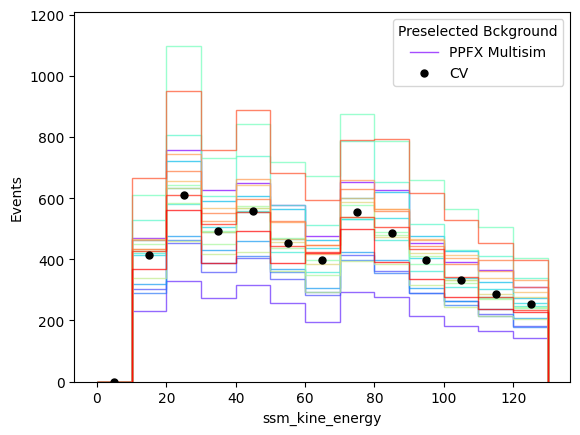

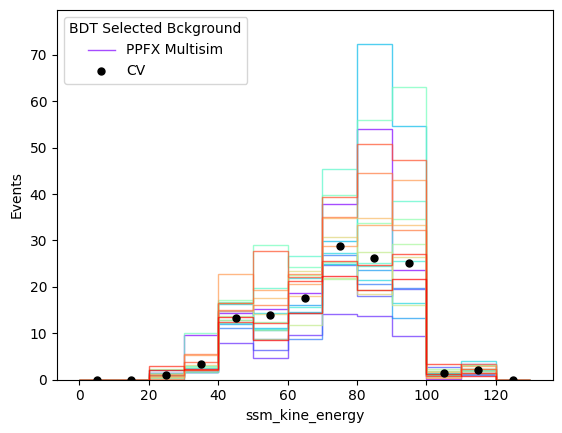

In [38]:
var = 'ssm_kine_energy'
xmin = 0
xmax = 130
nbins = 13
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=20)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=20)


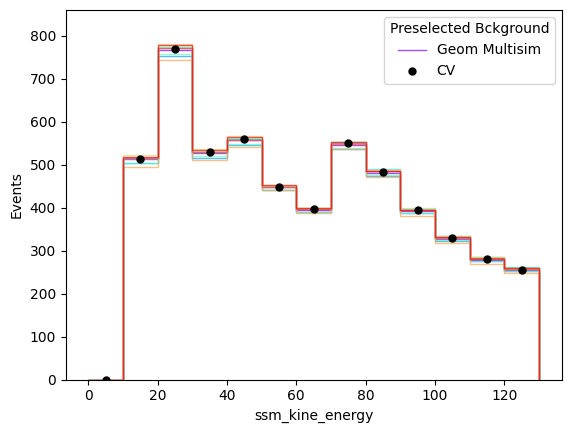

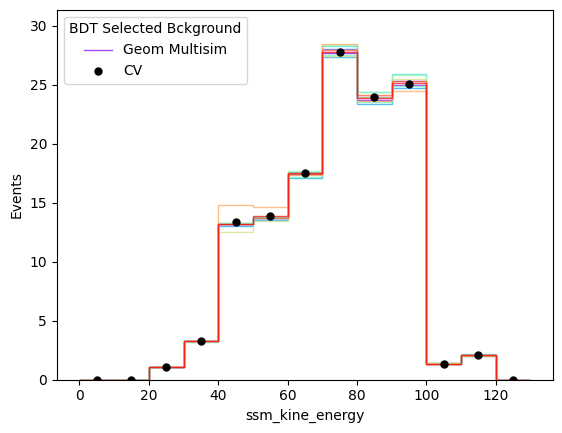

In [23]:
var = 'ssm_kine_energy'
xmin = 0
xmax = 130
nbins = 13
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=20)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=20)




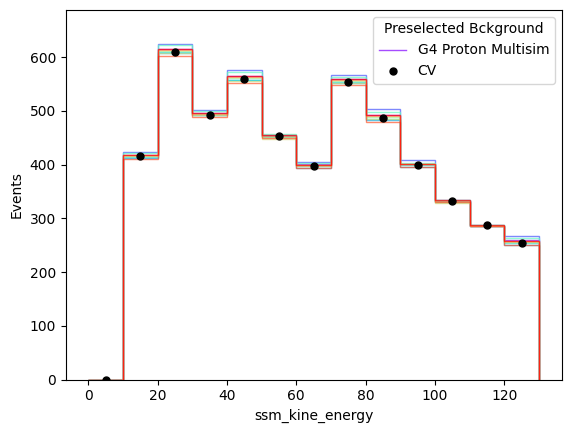

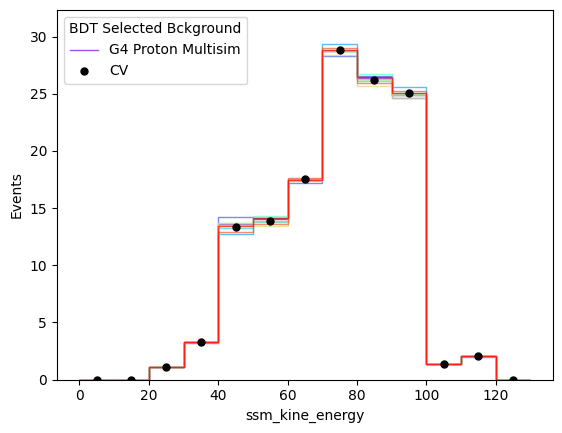

In [36]:
var = 'ssm_kine_energy'
xmin = 0
xmax = 130
nbins = 13
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

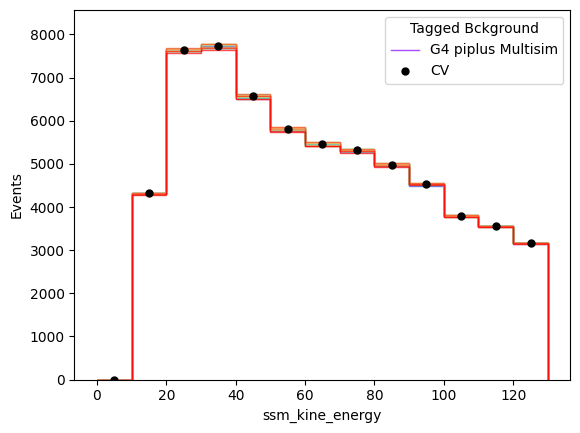

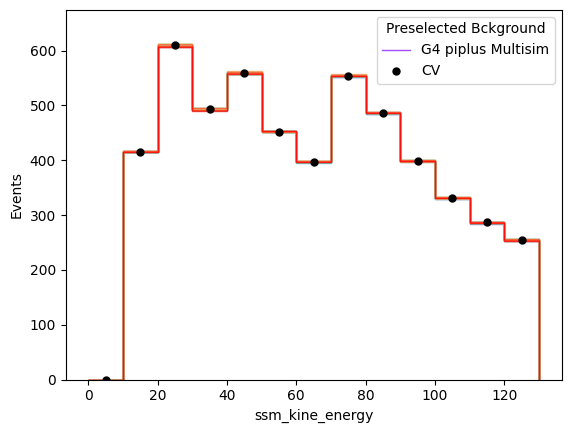

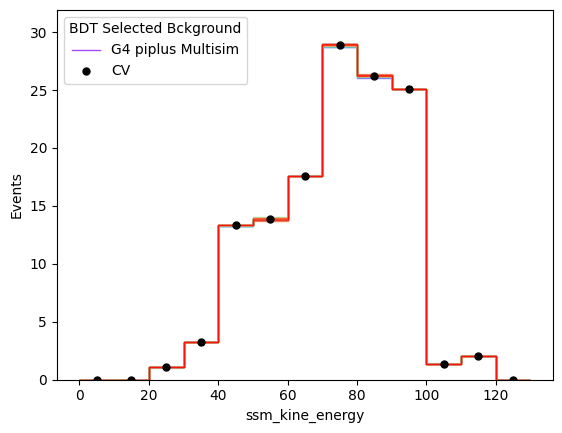

In [41]:
var = 'ssm_kine_energy'
xmin = 0
xmax = 130
nbins = 13
check_var(var,xmin,xmax,nbins,check_tagger=True,check_n_ppfx_uni=0,check_n_pip_uni=20)
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=20)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=20)

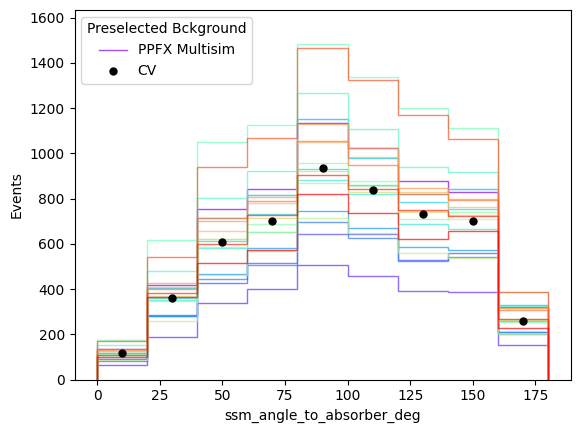

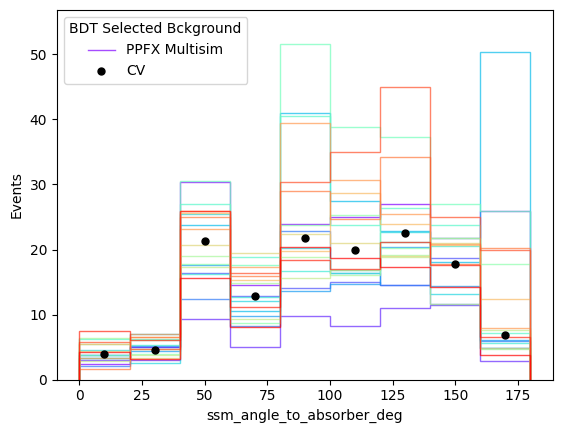

In [42]:
var = 'ssm_angle_to_absorber_deg'
xmin = 0
xmax = 180
nbins = 9
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=20)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=20)

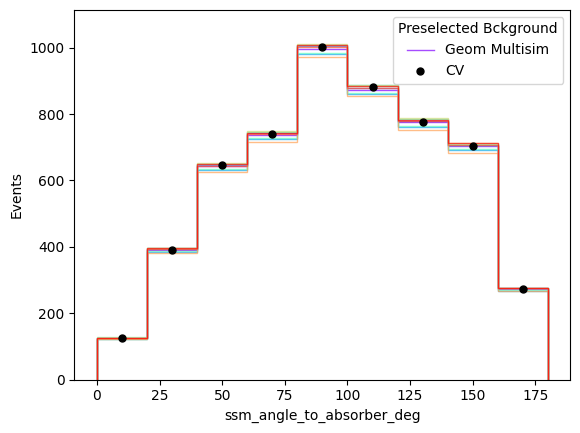

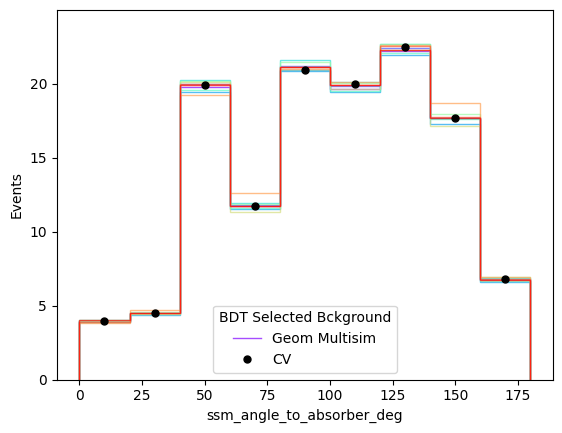

In [43]:
var = 'ssm_angle_to_absorber_deg'
xmin = 0
xmax = 180
nbins = 9
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

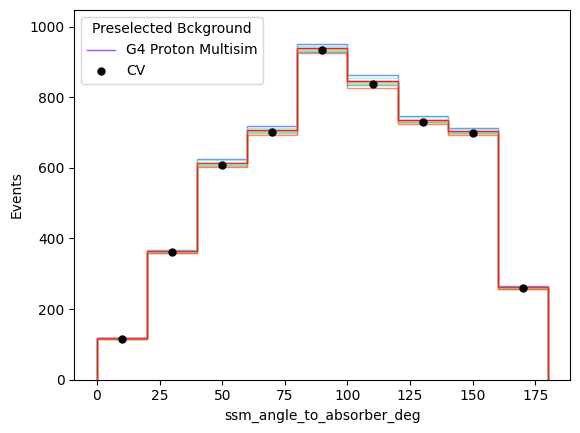

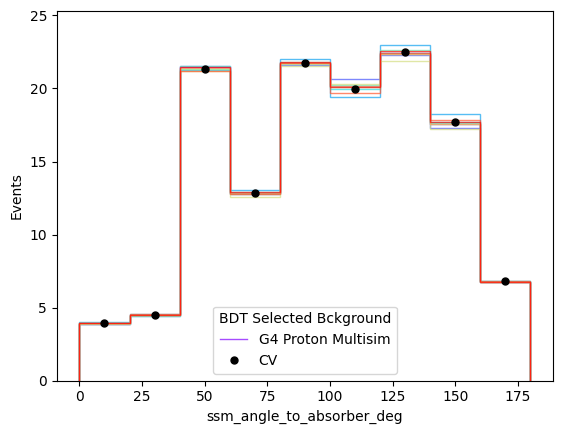

In [45]:
var = 'ssm_angle_to_absorber_deg'
xmin = 0
xmax = 180
nbins = 9
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

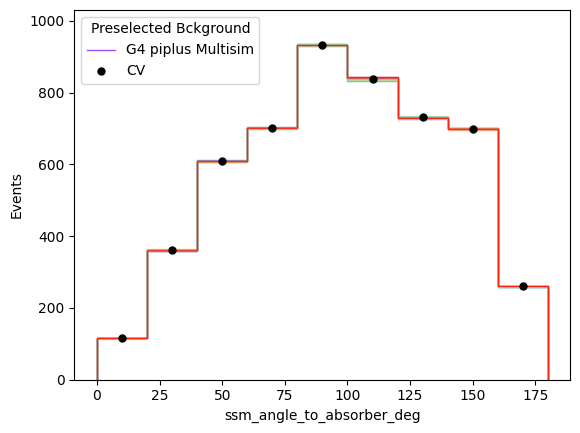

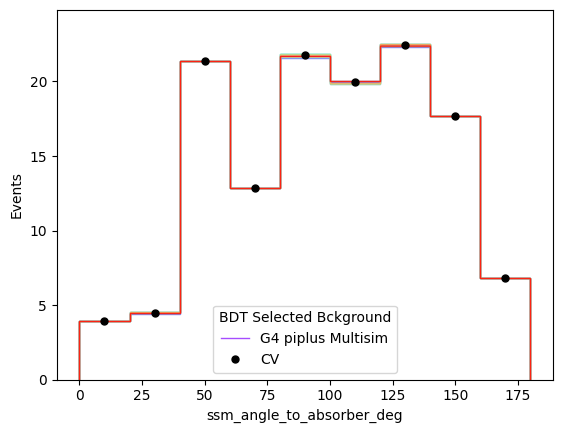

In [46]:
var = 'ssm_angle_to_absorber_deg'
xmin = 0
xmax = 180
nbins = 9
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)


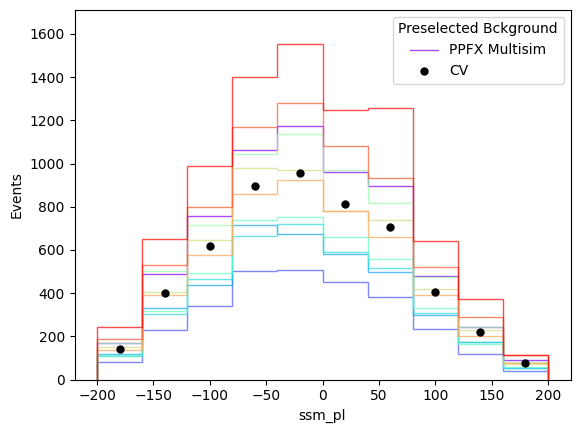

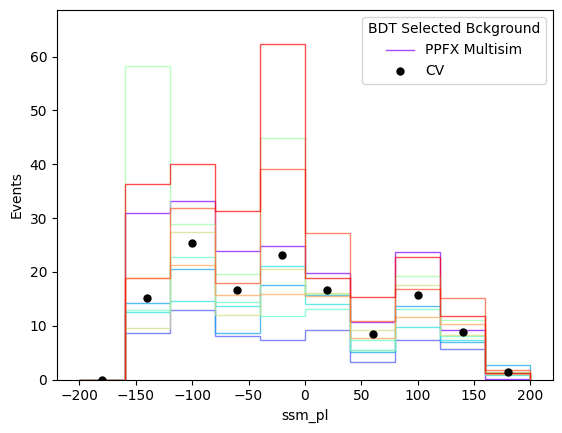

In [47]:
var = 'ssm_pl'
xmin = -200
xmax = 200
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

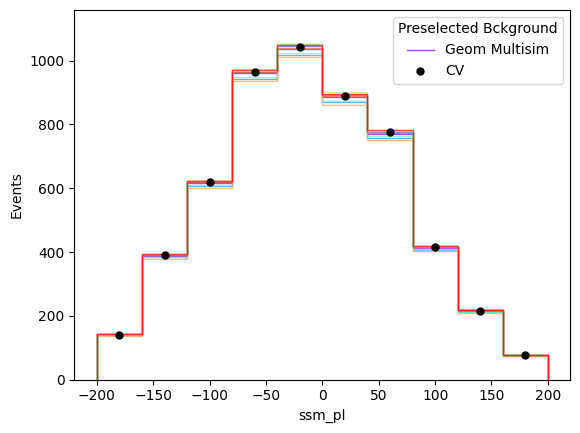

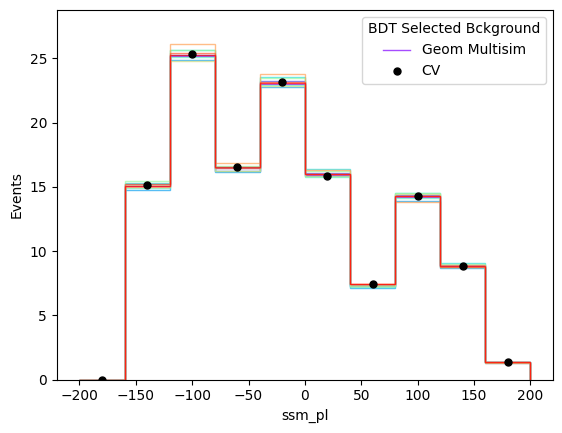

In [50]:
var = 'ssm_pl'
xmin = -200
xmax = 200
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

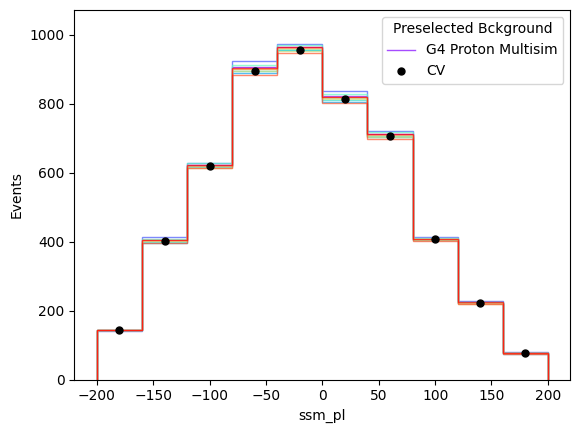

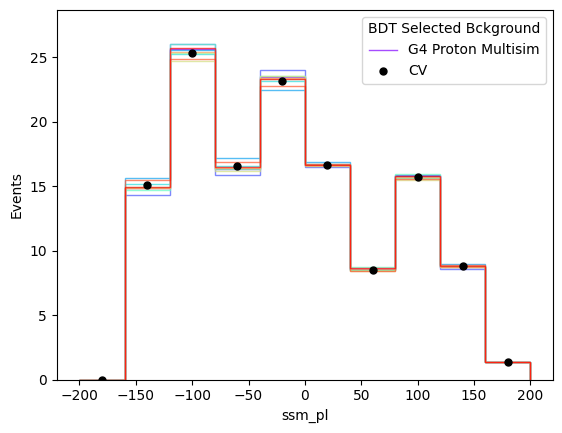

In [49]:
var = 'ssm_pl'
xmin = -200
xmax = 200
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

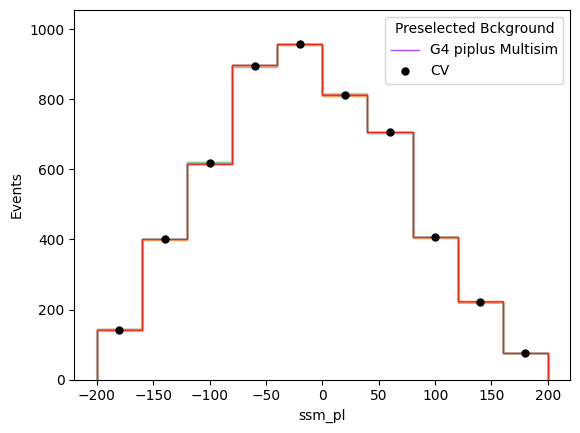

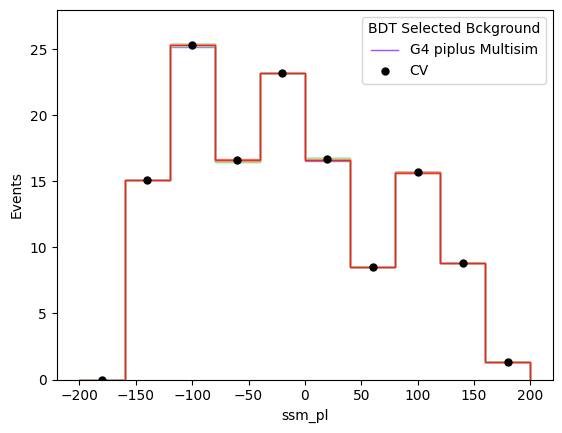

In [48]:
var = 'ssm_pl'
xmin = -200
xmax = 200
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

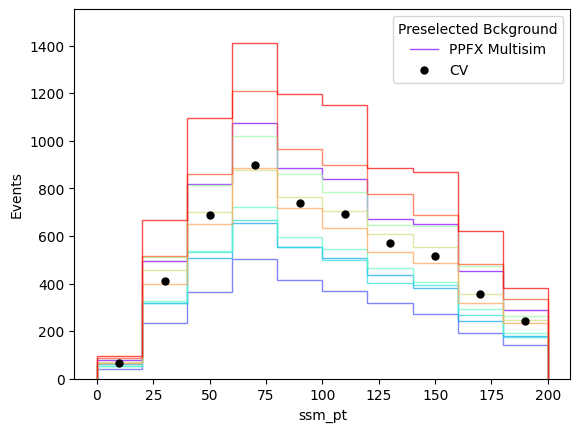

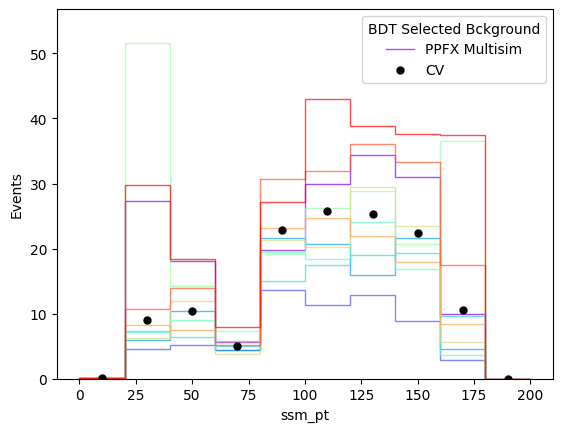

In [51]:
var = 'ssm_pt'
xmin = 0
xmax = 200
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

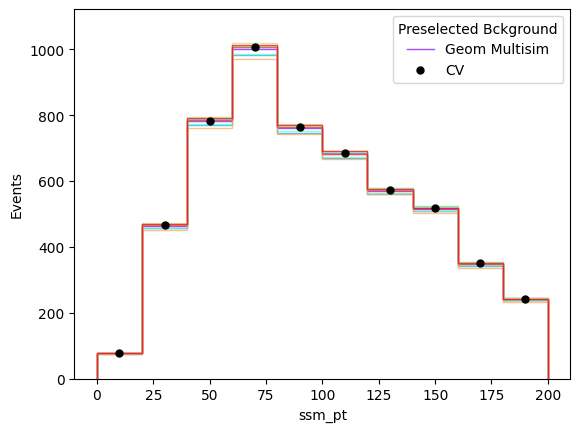

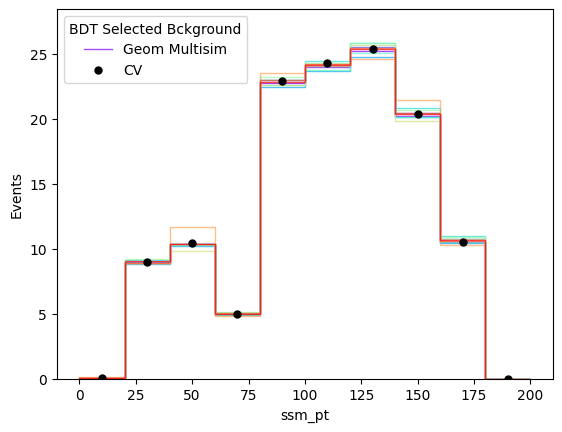

In [53]:

var = 'ssm_pt'
xmin = 0
xmax = 200
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

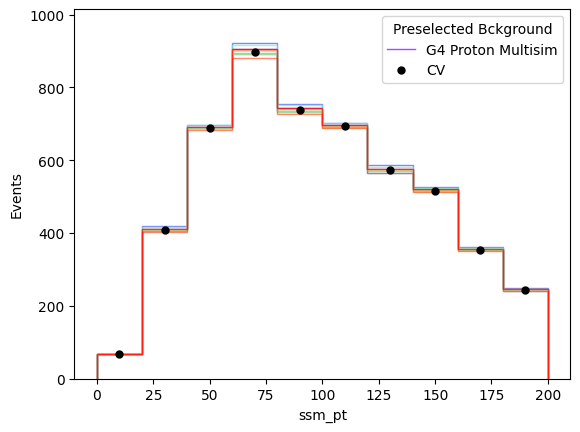

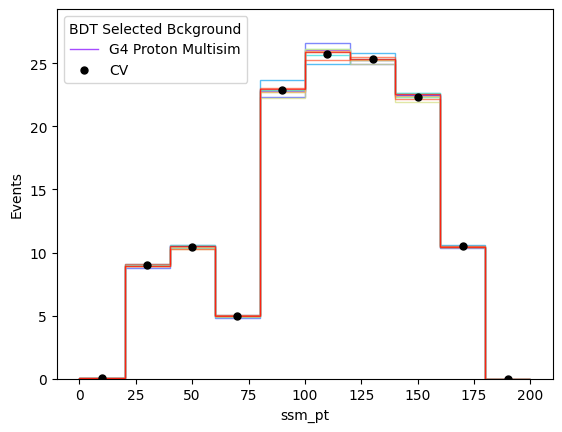

In [54]:
var = 'ssm_pt'
xmin = 0
xmax = 200
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

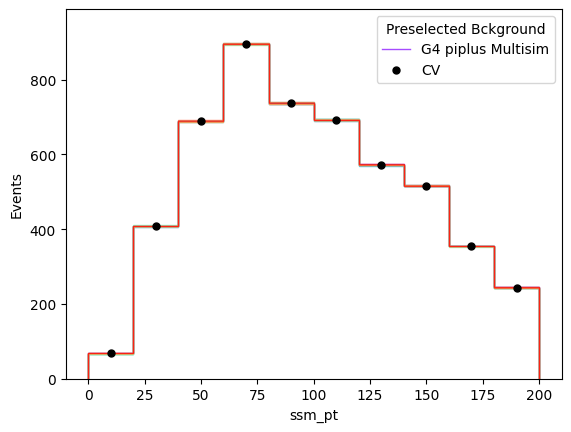

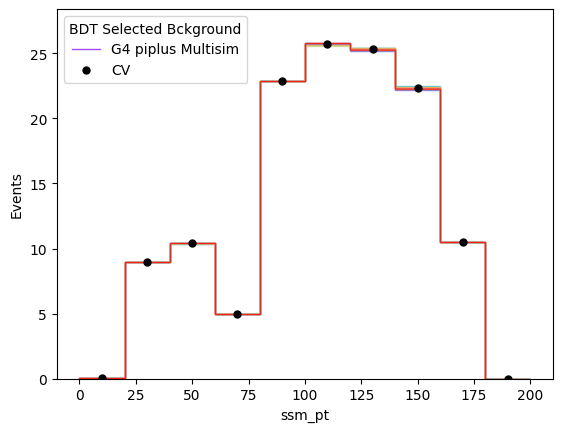

In [55]:
var = 'ssm_pt'
xmin = 0
xmax = 200
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

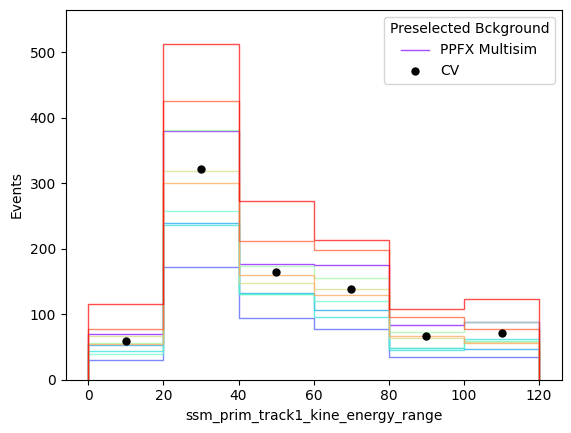

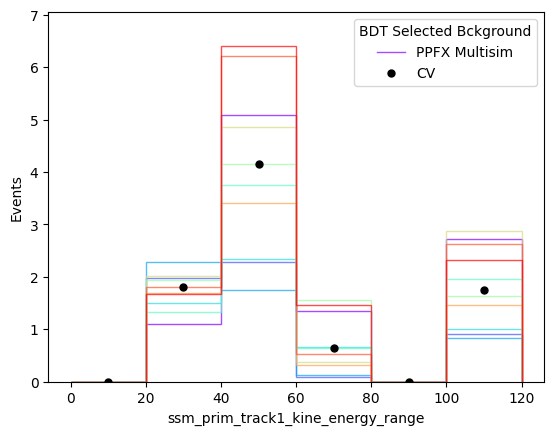

In [59]:
var = 'ssm_prim_track1_kine_energy_range'
xmin = 0
xmax = 120
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

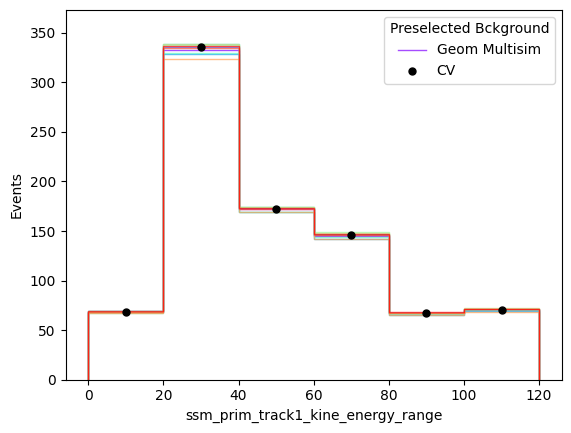

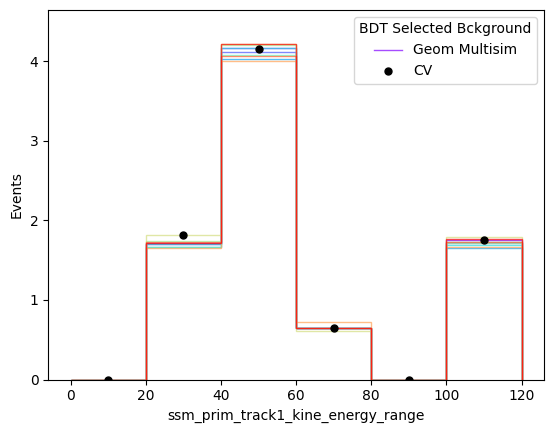

In [63]:
var = 'ssm_prim_track1_kine_energy_range'
xmin = 0
xmax = 120
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

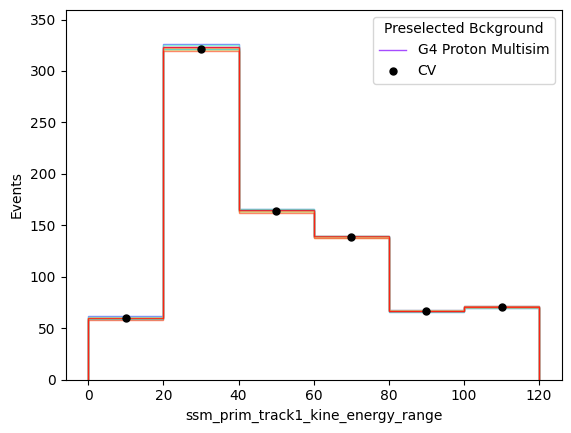

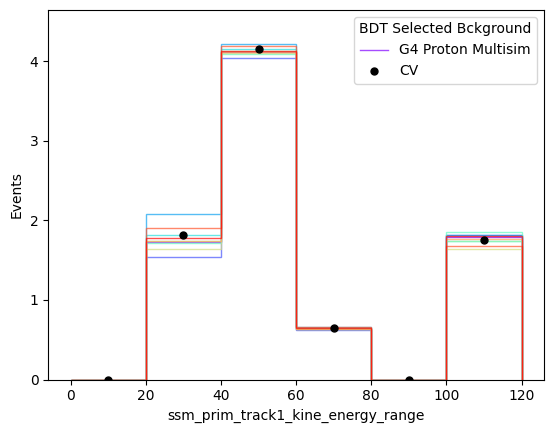

In [64]:
var = 'ssm_prim_track1_kine_energy_range'
xmin = 0
xmax = 120
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

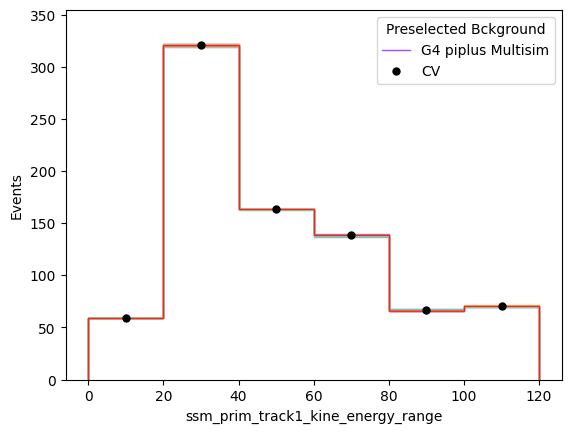

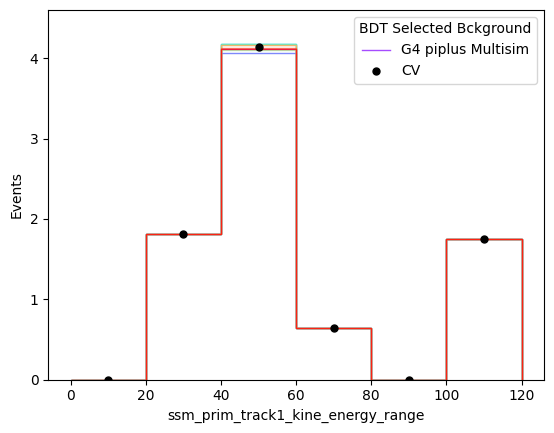

In [65]:
var = 'ssm_prim_track1_kine_energy_range'
xmin = 0
xmax = 120
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

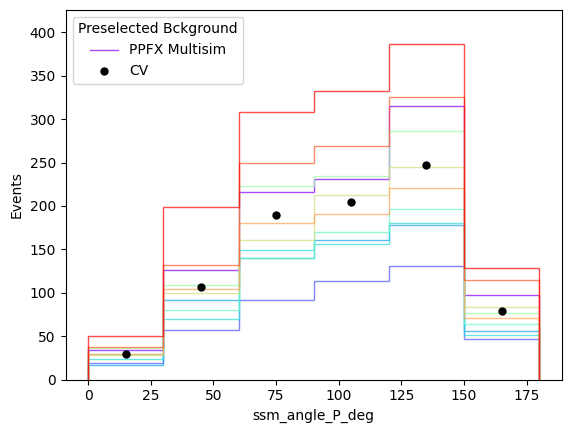

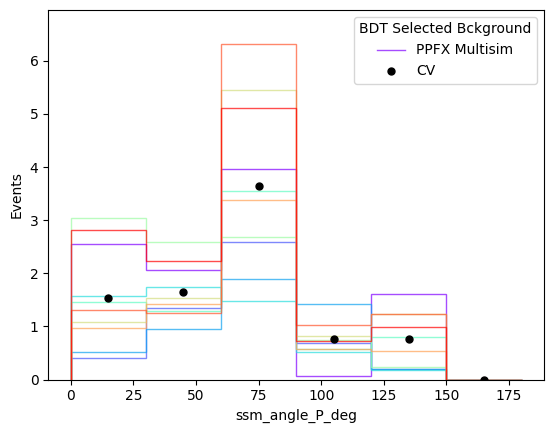

In [66]:
var = 'ssm_angle_P_deg'
xmin = 0
xmax = 180
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

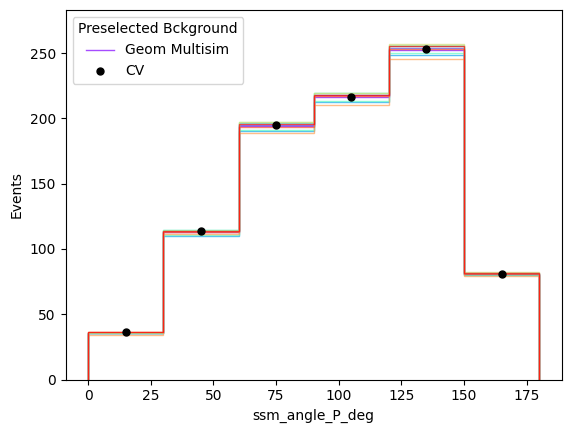

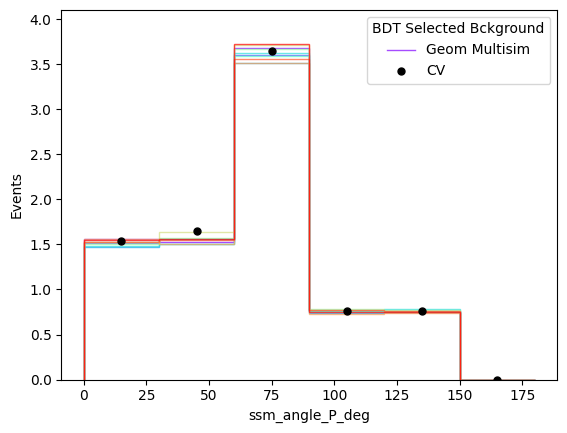

In [69]:
var = 'ssm_angle_P_deg'
xmin = 0
xmax = 180
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

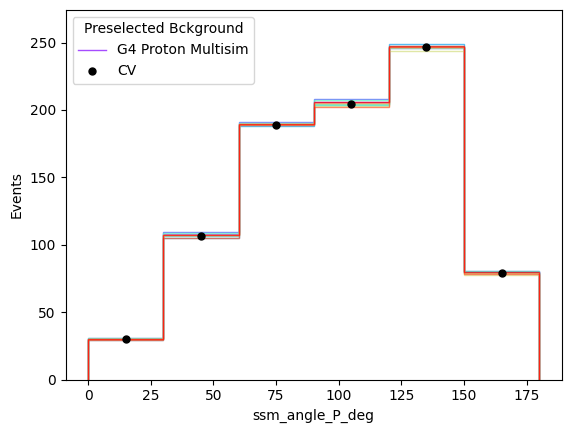

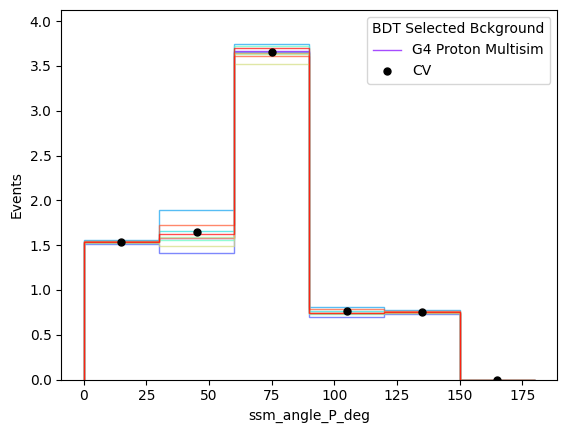

In [68]:
var = 'ssm_angle_P_deg'
xmin = 0
xmax = 180
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

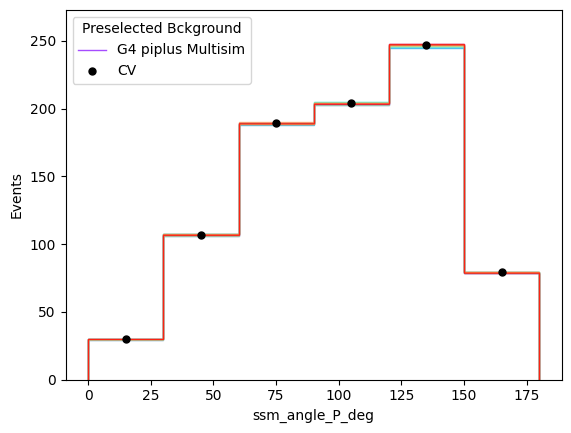

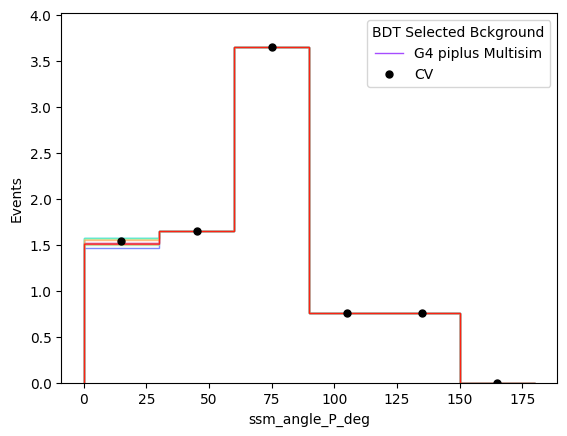

In [67]:
var = 'ssm_angle_P_deg'
xmin = 0
xmax = 180
nbins = 6
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

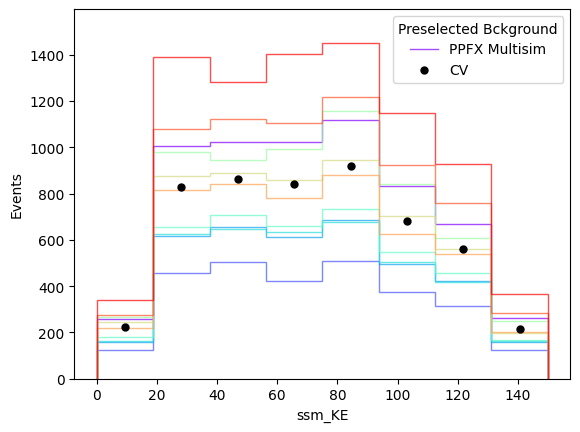

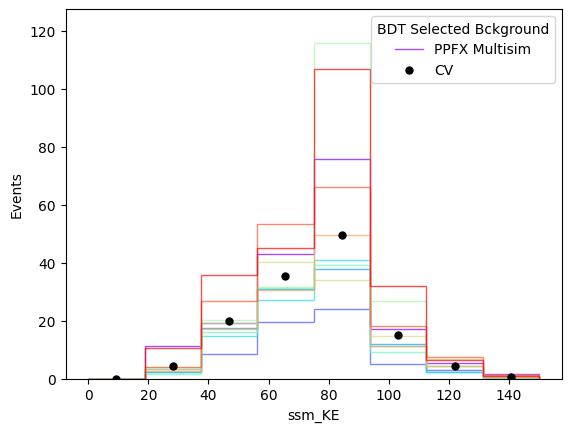

In [70]:
var = 'ssm_KE'
xmin = 0
xmax = 150
nbins = 8

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

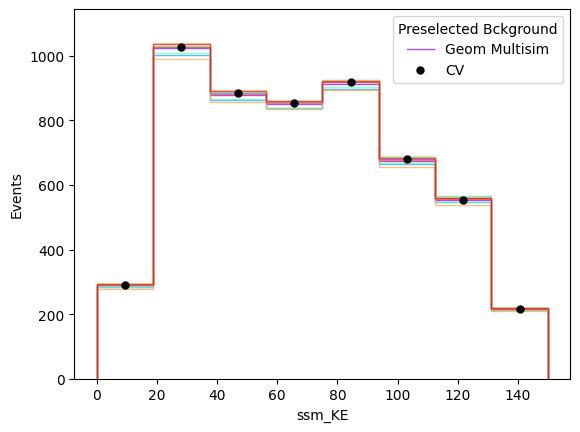

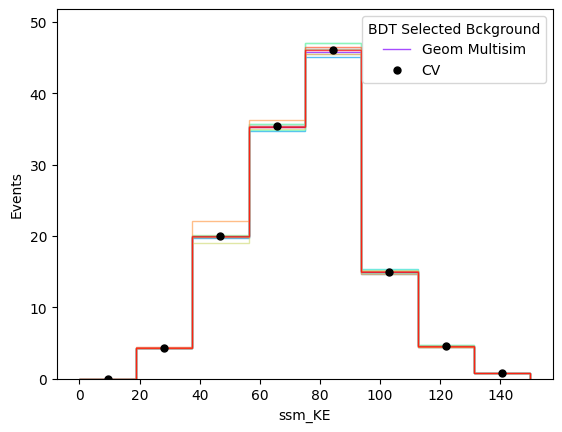

In [74]:
var = 'ssm_KE'
xmin = 0
xmax = 150
nbins = 8

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

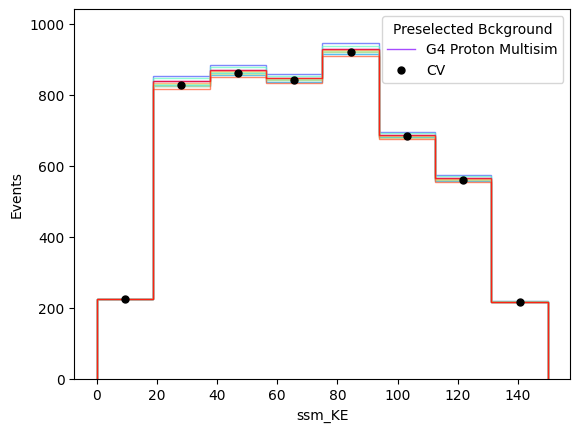

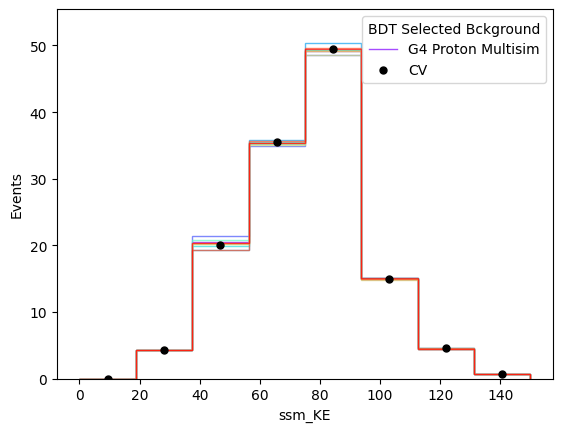

In [73]:
var = 'ssm_KE'
xmin = 0
xmax = 150
nbins = 8

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

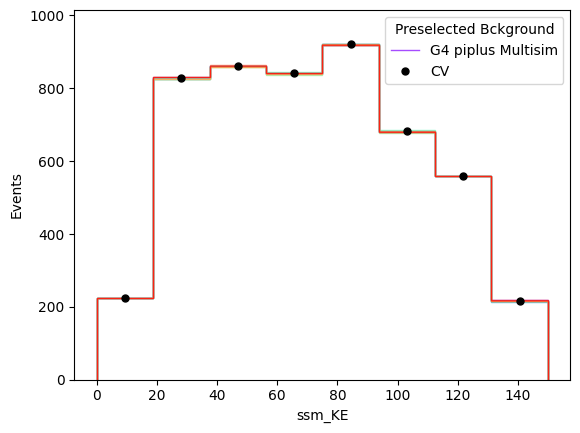

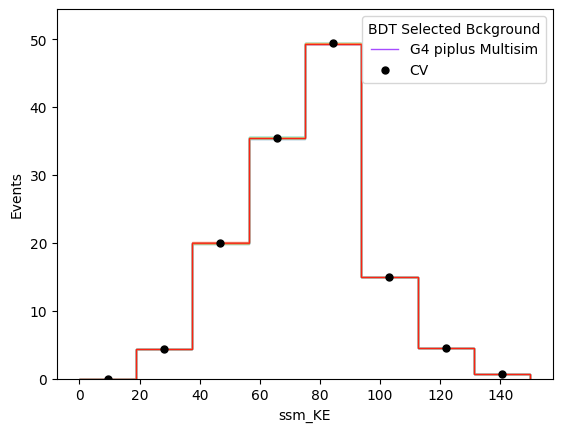

In [75]:
var = 'ssm_KE'
xmin = 0
xmax = 150
nbins = 8

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

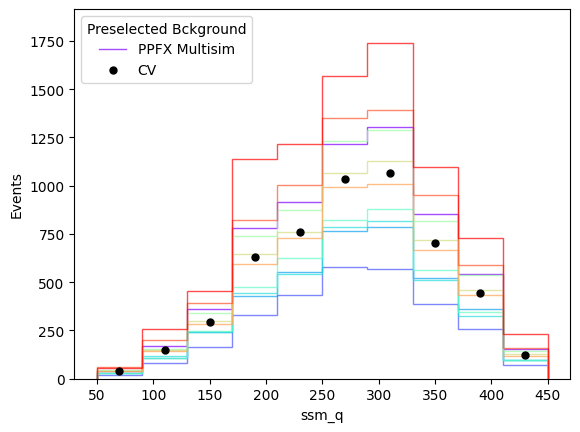

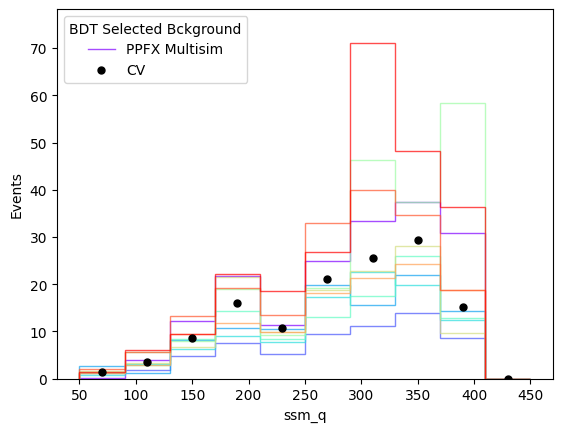

In [76]:
var = 'ssm_q'
xmin = 50
xmax = 450
nbins = 10


check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_geom_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_geom_uni=0)

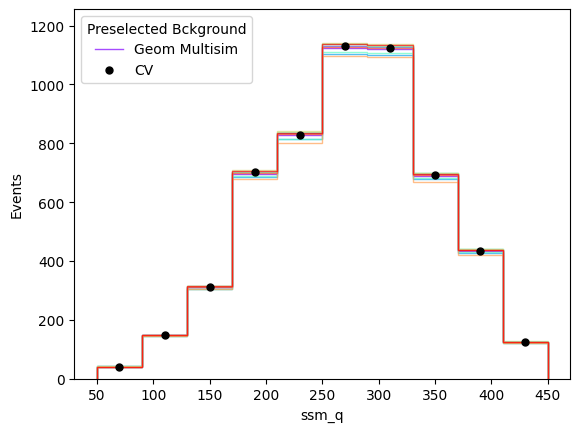

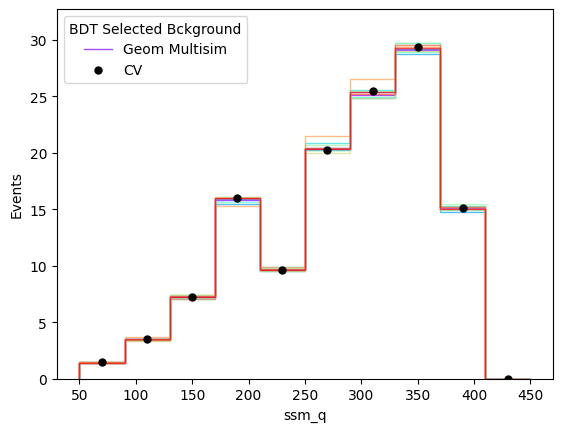

In [77]:
var = 'ssm_q'
xmin = 50
xmax = 450
nbins = 10


check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

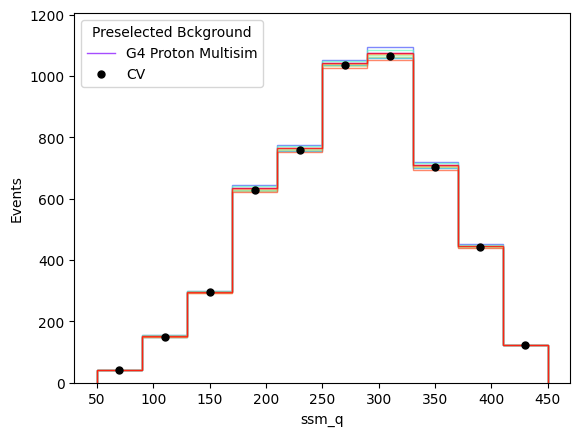

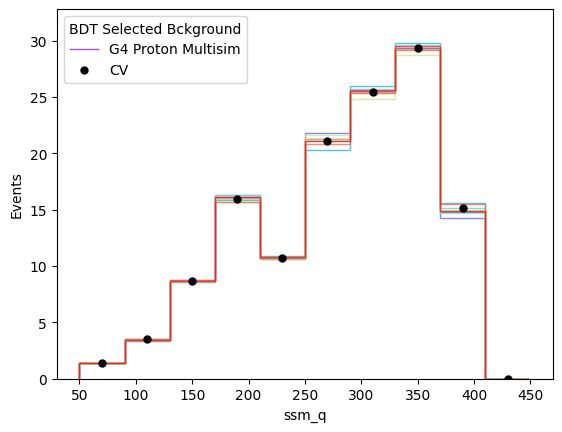

In [78]:
var = 'ssm_q'
xmin = 50
xmax = 450
nbins = 10


check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

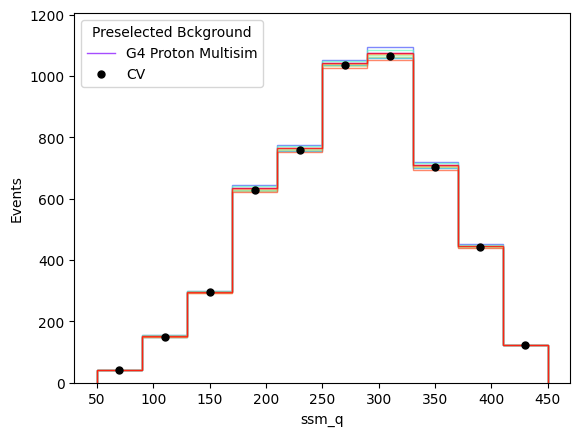

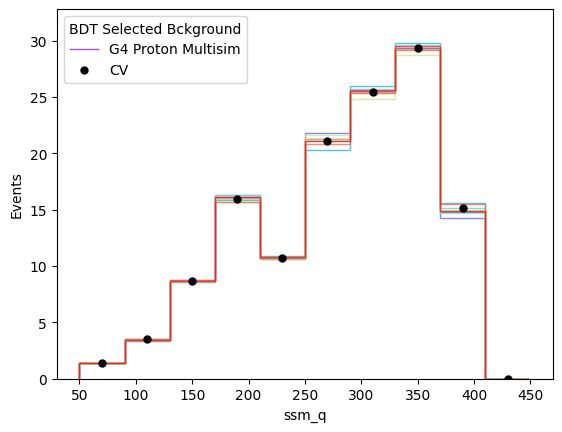

In [79]:
var = 'ssm_q'
xmin = 50
xmax = 450
nbins = 10


check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

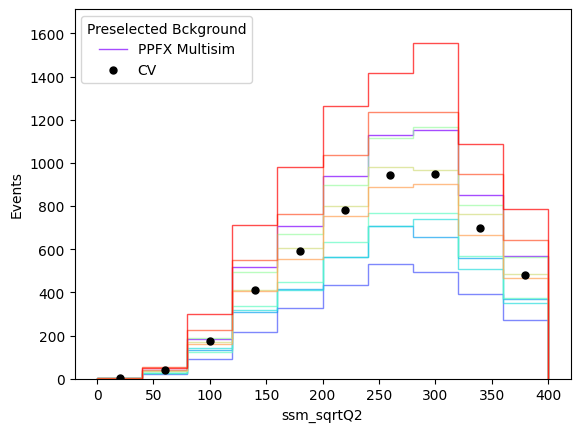

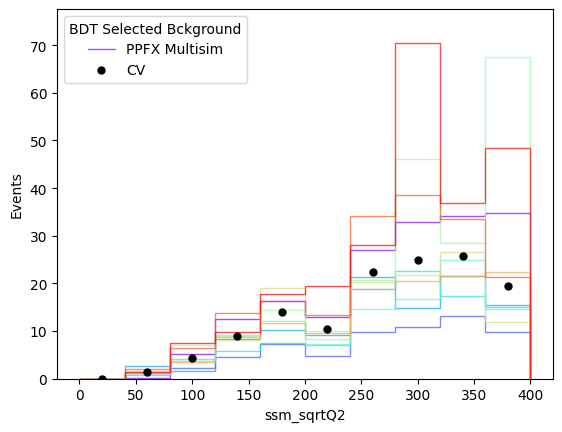

In [81]:
var = 'ssm_sqrtQ2'
xmin = 0
xmax = 400
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_p_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_p_uni=0)

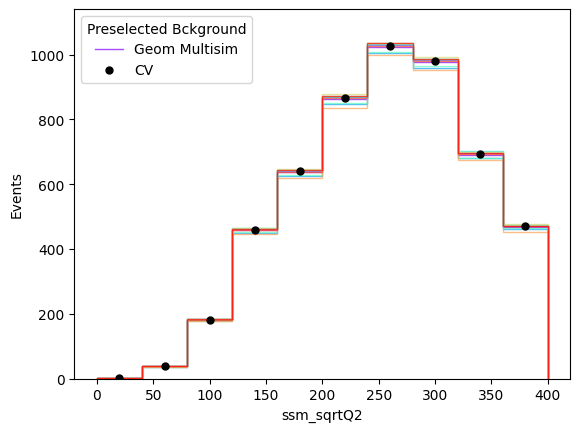

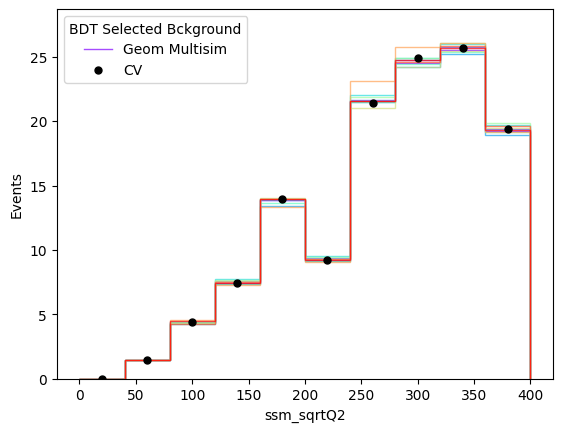

In [82]:
var = 'ssm_sqrtQ2'
xmin = 0
xmax = 400
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

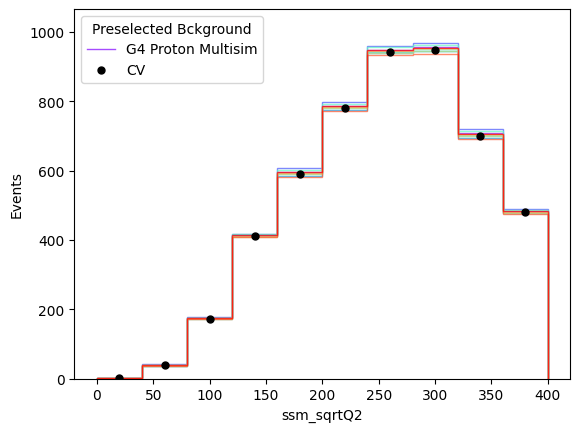

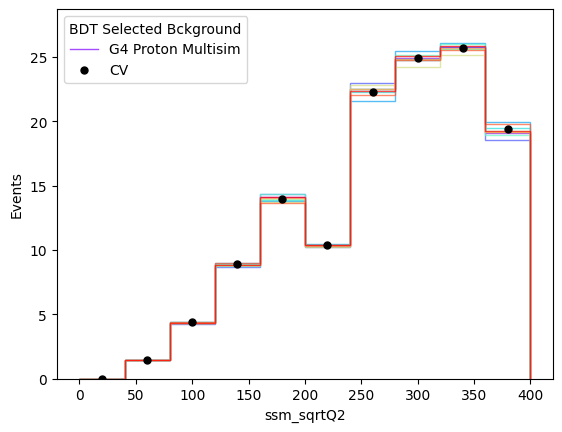

In [83]:
var = 'ssm_sqrtQ2'
xmin = 0
xmax = 400
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

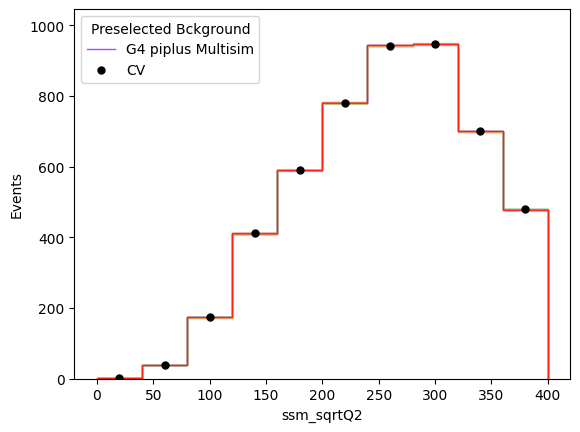

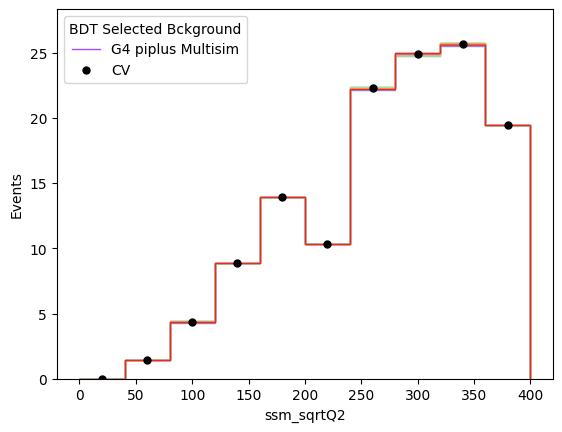

In [84]:
var = 'ssm_sqrtQ2'
xmin = 0
xmax = 400
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

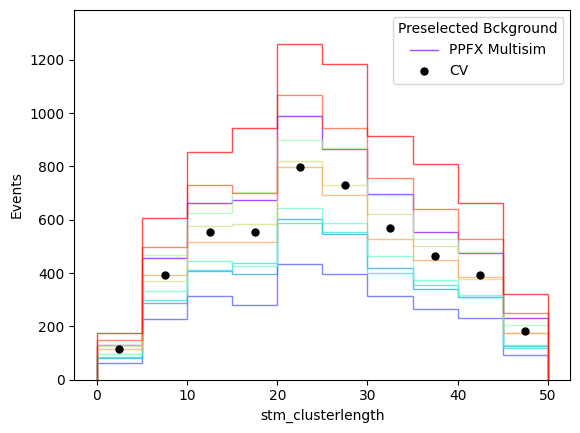

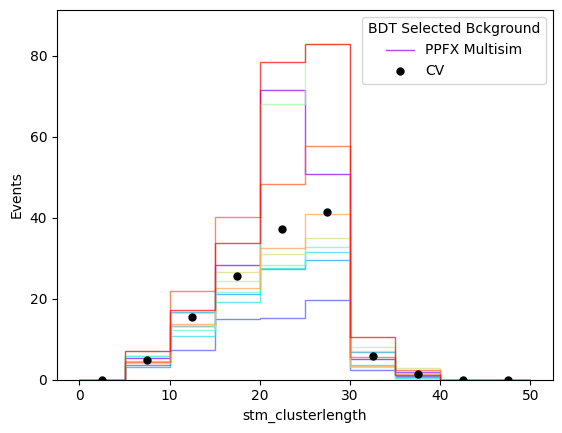

In [85]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_p_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_p_uni=0)


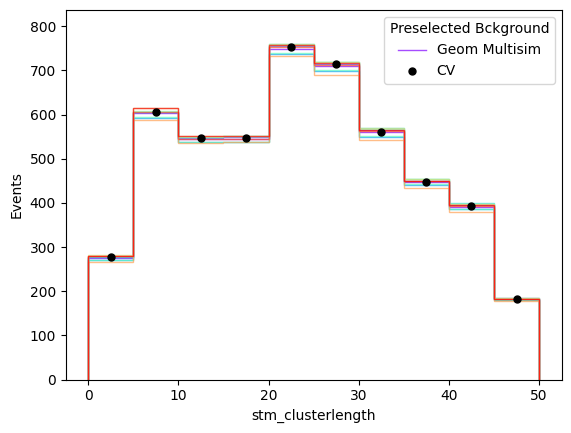

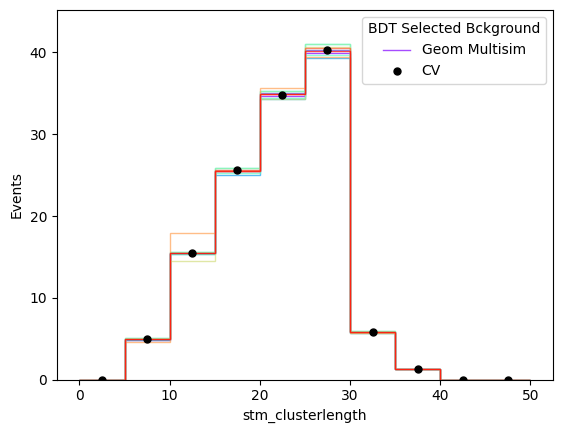

In [86]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

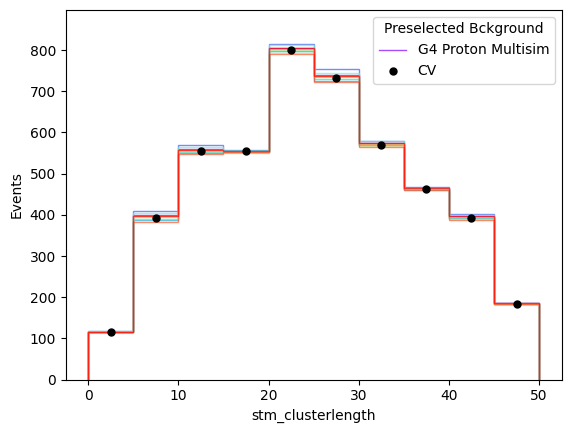

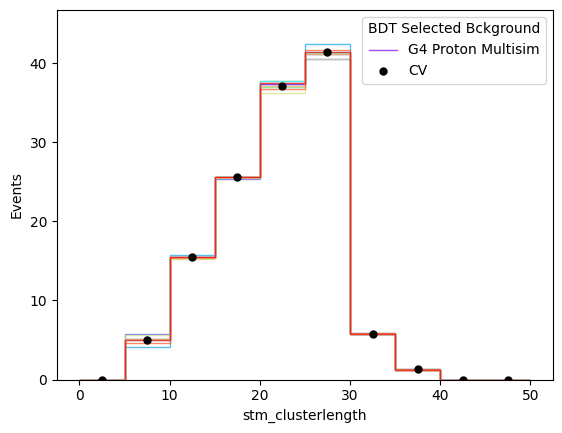

In [87]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

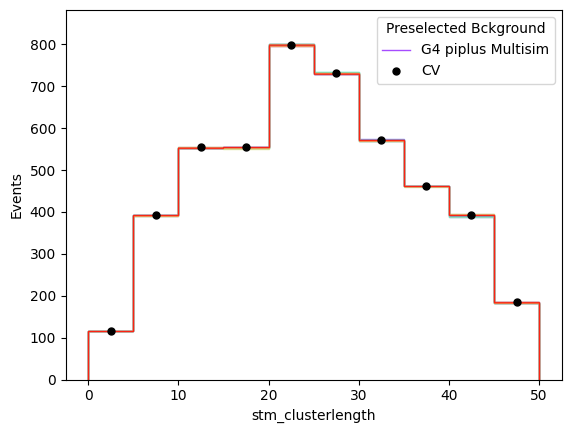

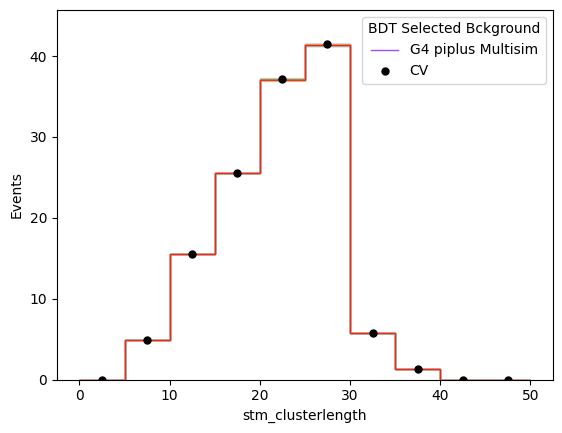

In [88]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

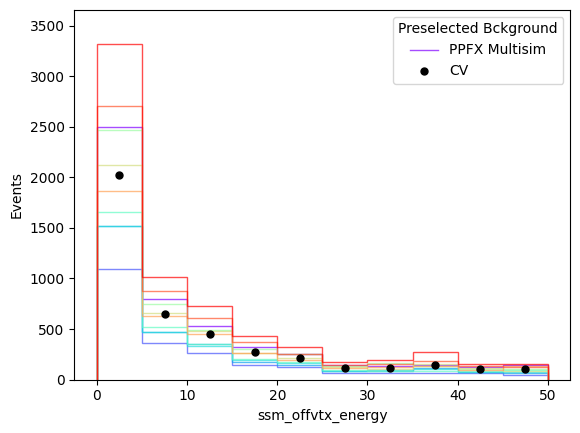

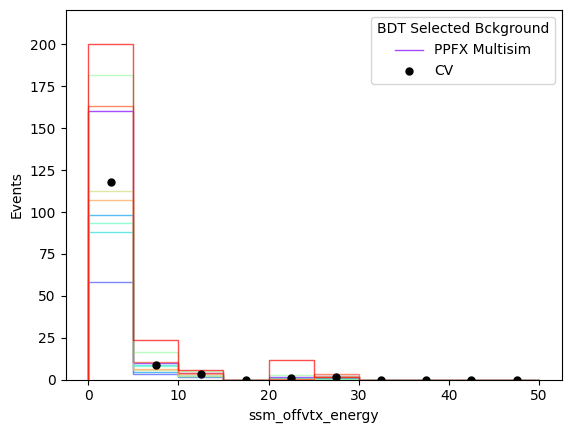

In [89]:
var = 'ssm_offvtx_energy'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_p_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_p_uni=0)

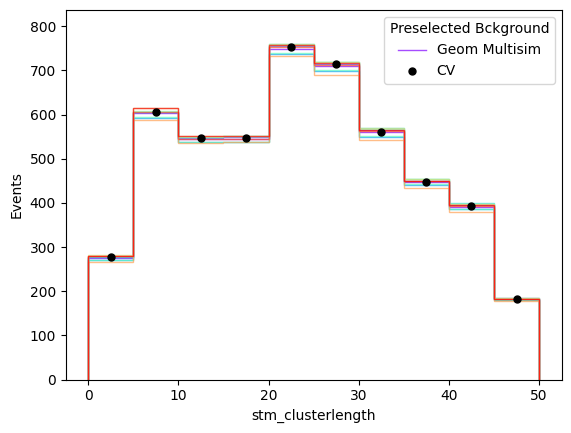

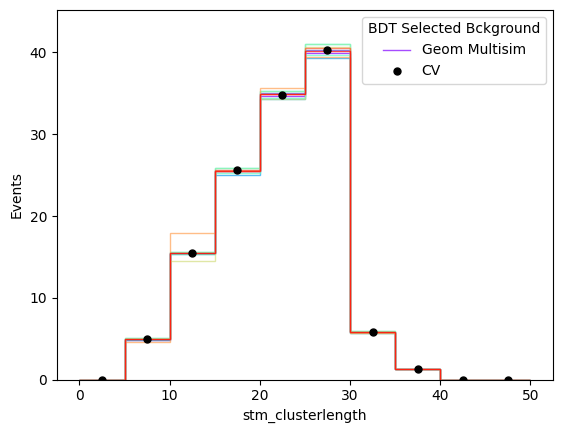

In [90]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

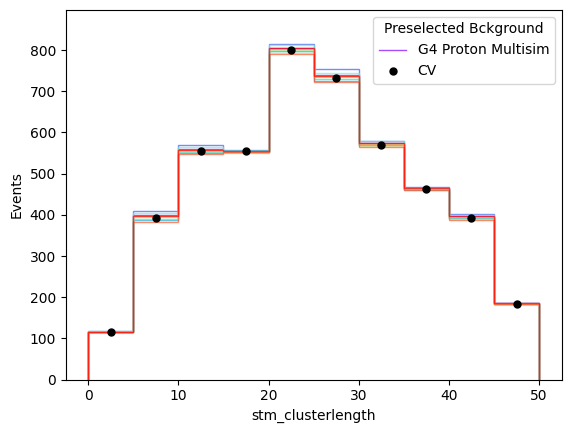

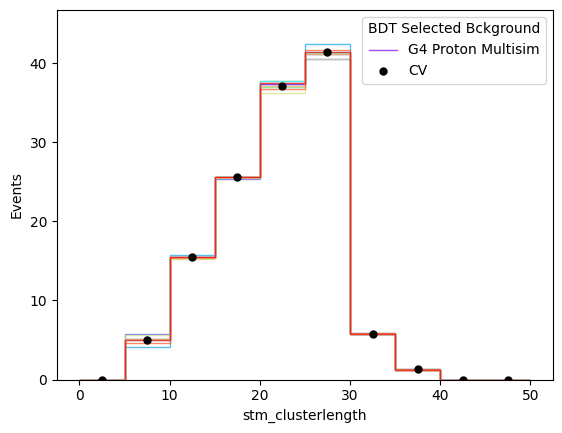

In [91]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

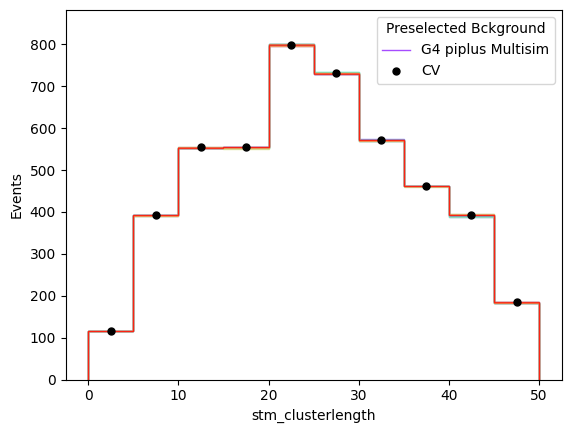

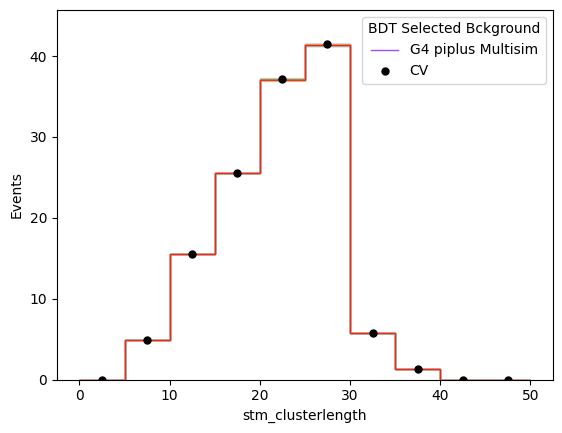

In [92]:
var = 'stm_clusterlength'
xmin = 0
xmax = 50
nbins = 10

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

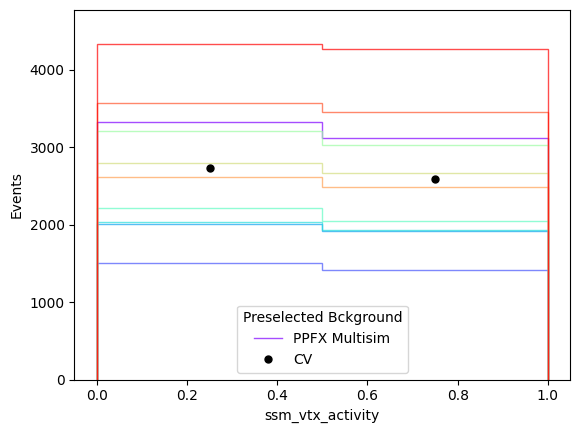

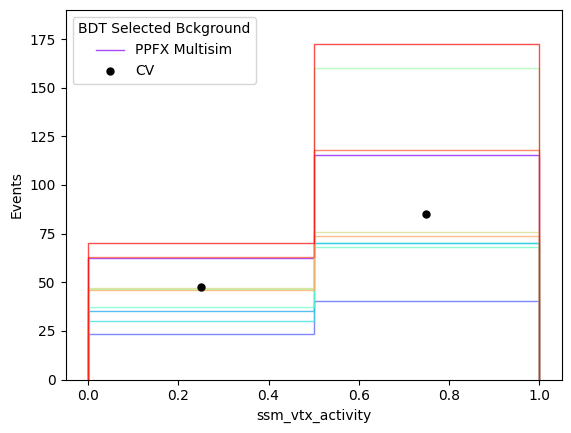

In [93]:
var = 'ssm_vtx_activity'
xmin = 0
xmax = 1
nbins = 2

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_p_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_p_uni=0)

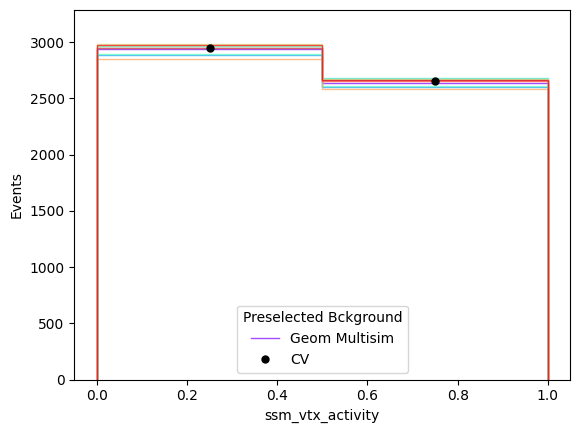

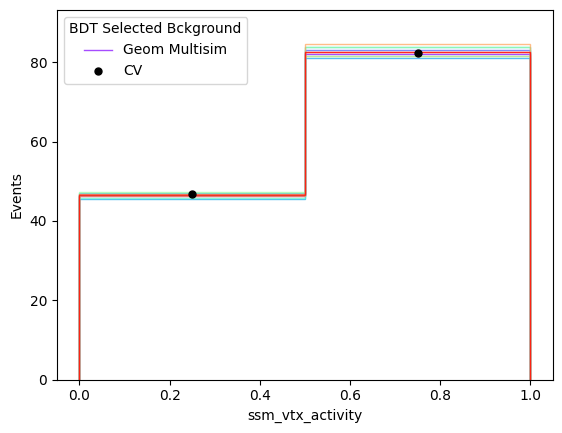

In [95]:
var = 'ssm_vtx_activity'
xmin = 0
xmax = 1
nbins = 2

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

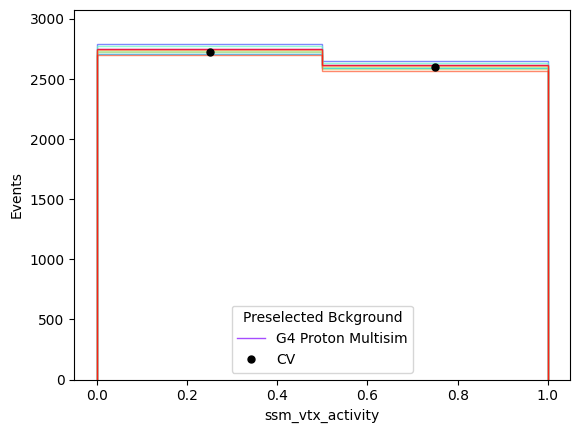

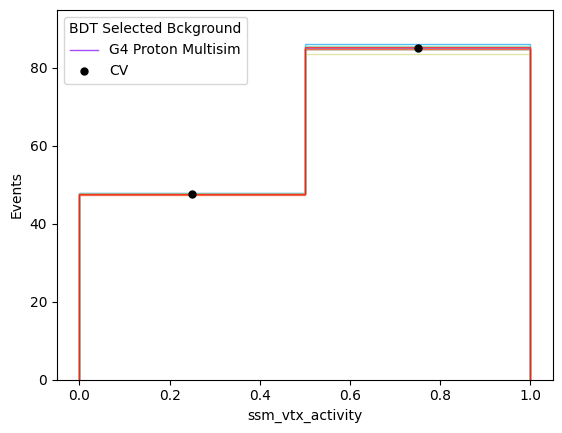

In [96]:
var = 'ssm_vtx_activity'
xmin = 0
xmax = 1
nbins = 2

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

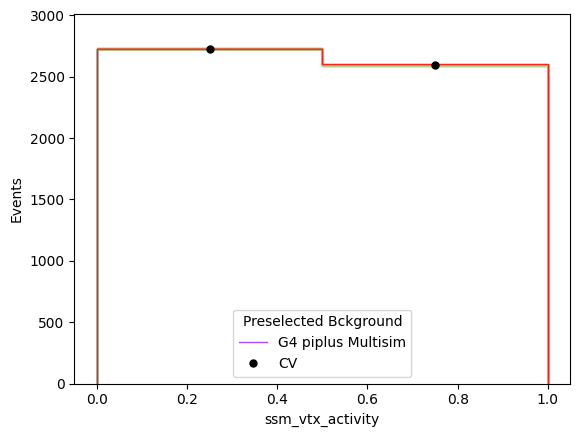

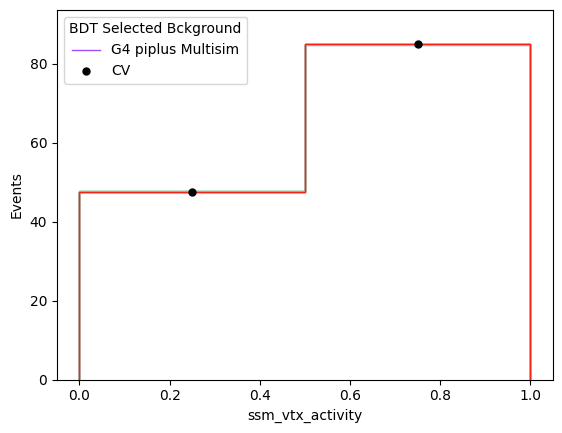

In [97]:
var = 'ssm_vtx_activity'
xmin = 0
xmax = 1
nbins = 2

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

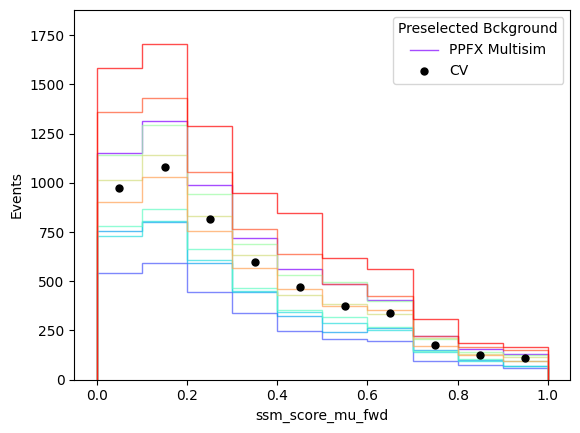

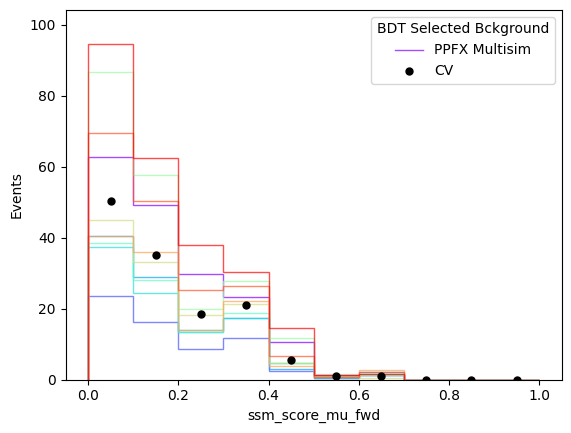

In [99]:
var = 'ssm_score_mu_fwd'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_p_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_p_uni=0)

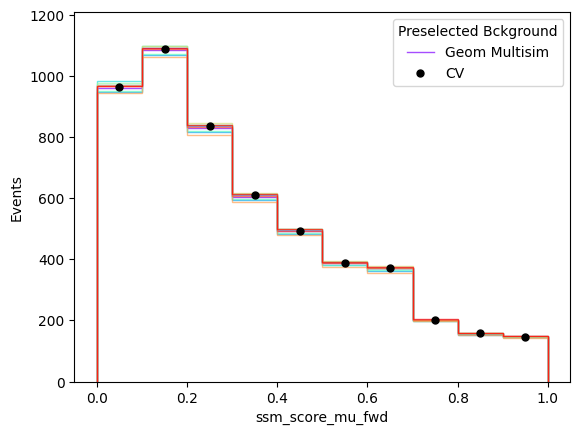

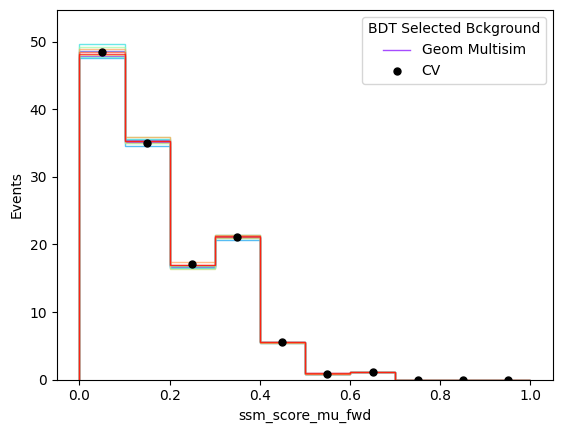

In [100]:
var = 'ssm_score_mu_fwd'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

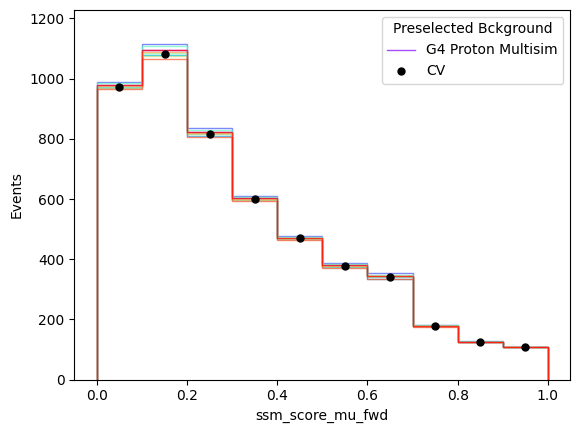

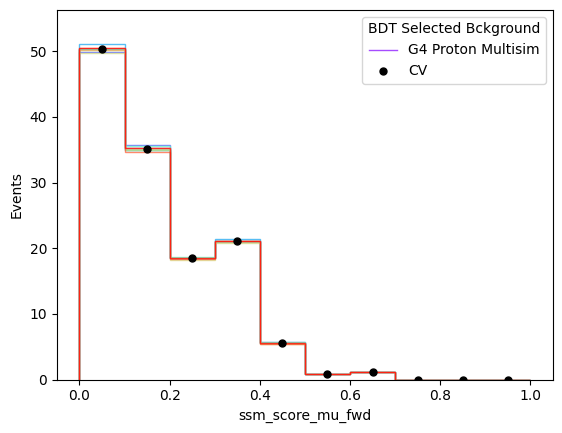

In [101]:
var = 'ssm_score_mu_fwd'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

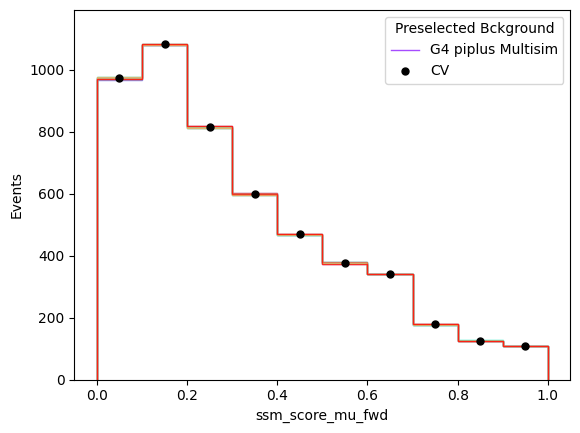

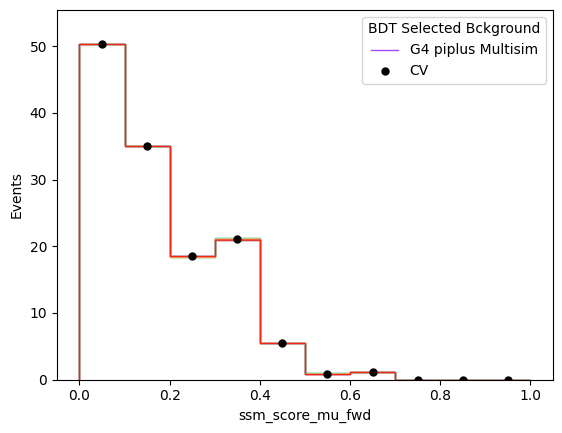

In [102]:
var = 'ssm_score_mu_fwd'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

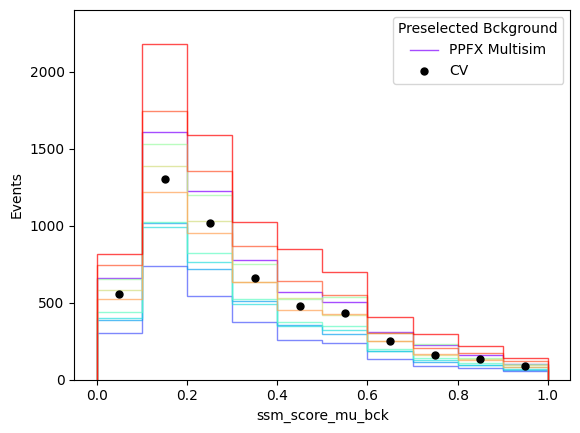

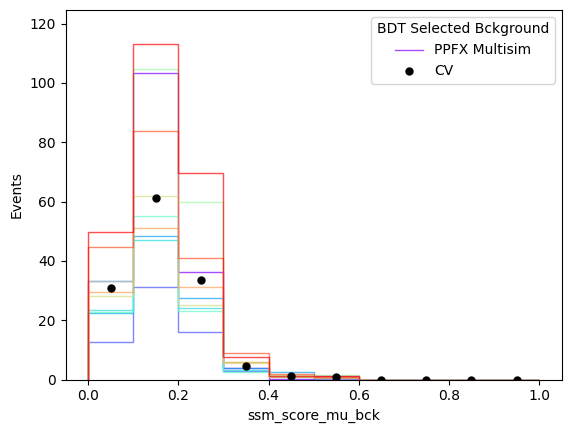

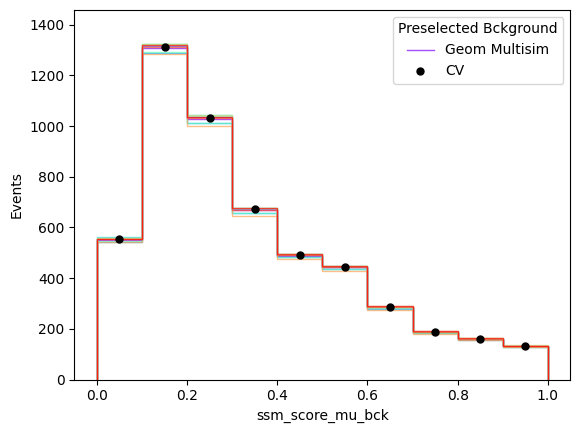

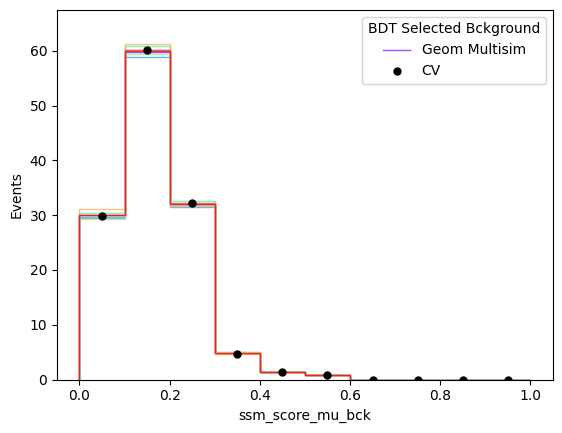

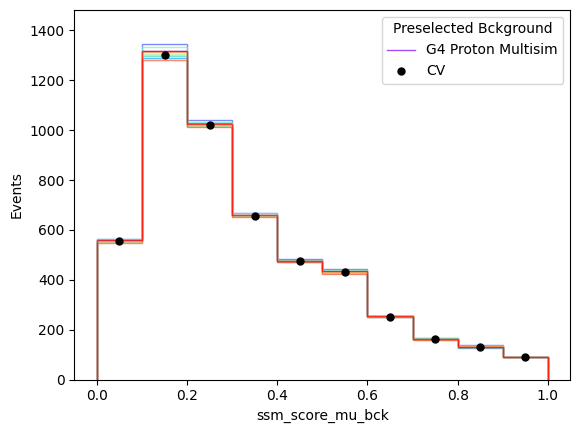

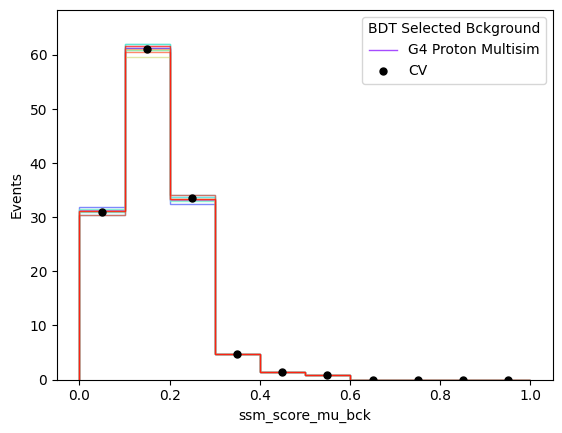

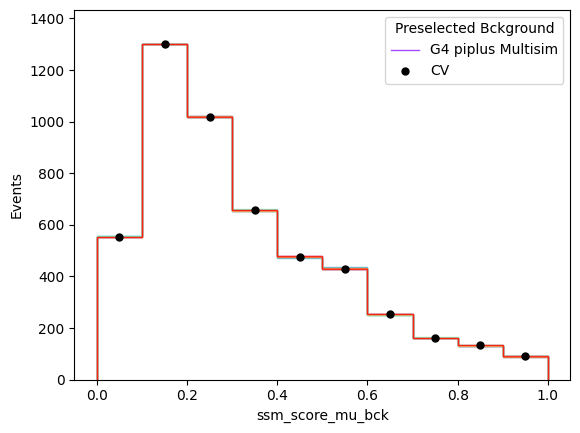

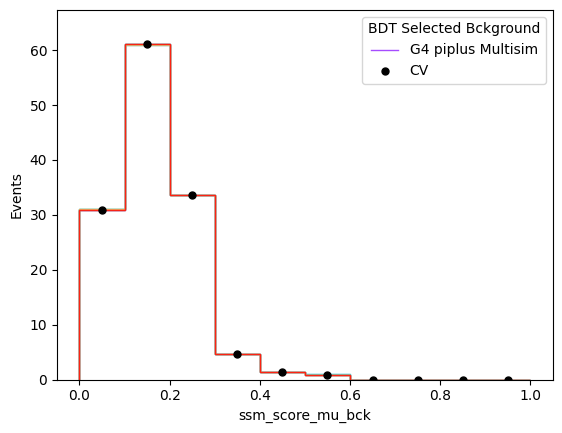

In [103]:
var = 'ssm_score_mu_bck'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

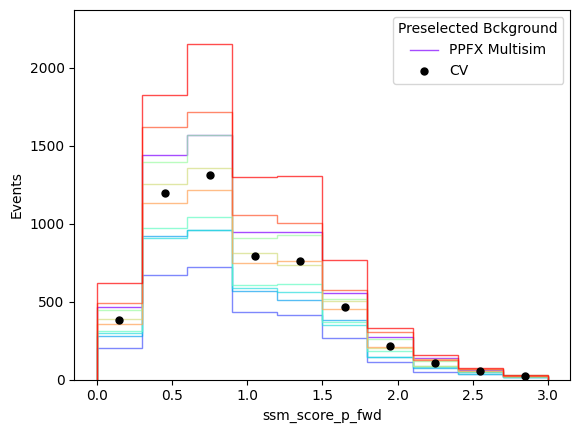

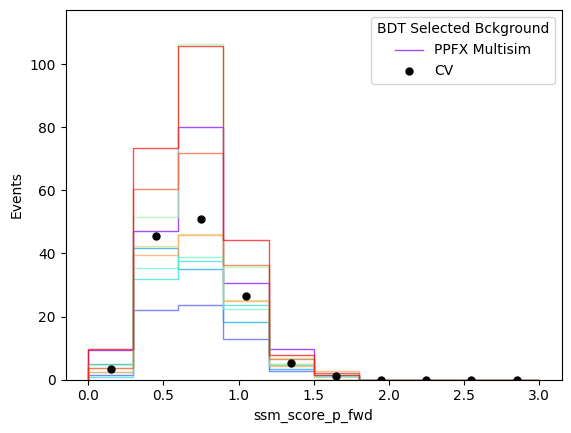

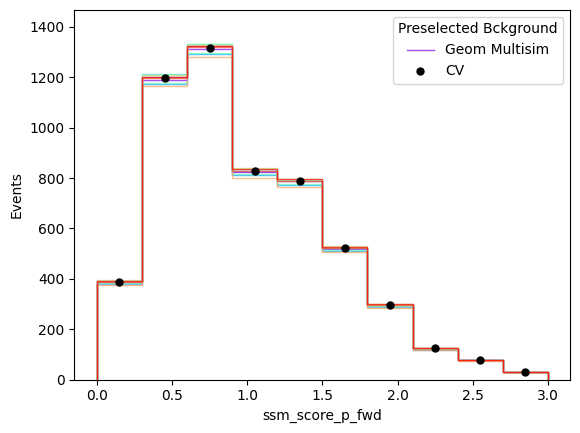

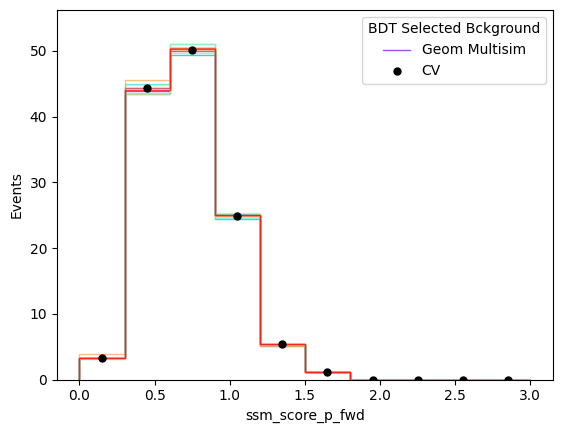

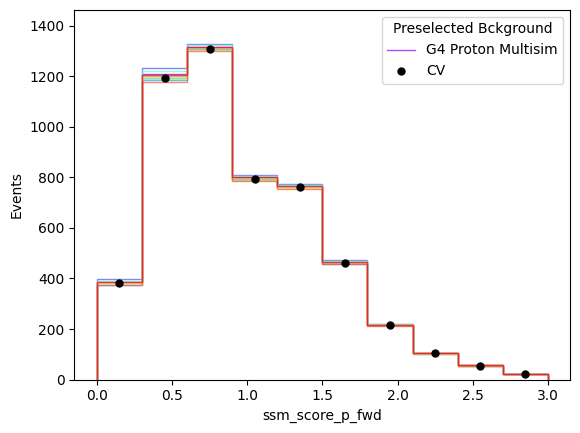

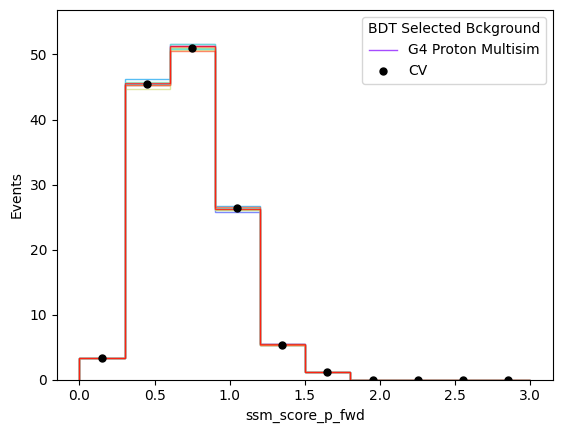

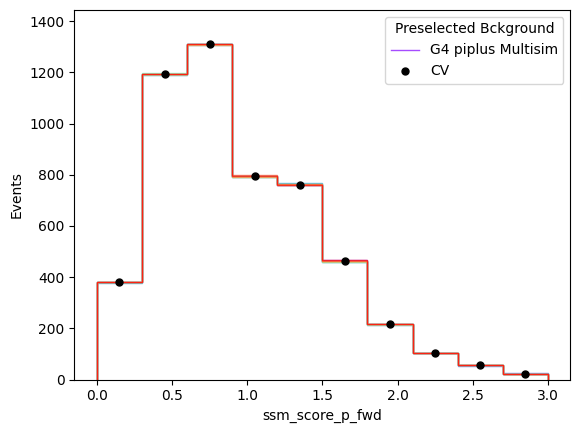

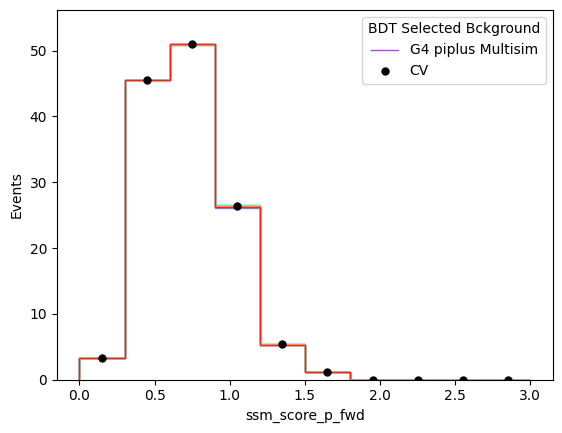

In [104]:
var = 'ssm_score_p_fwd'
xmin = 0
xmax = 3
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

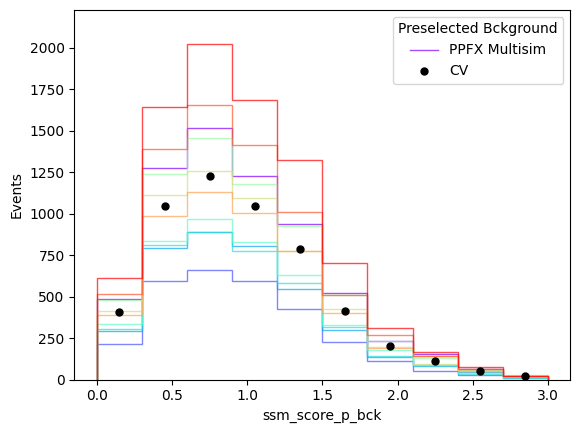

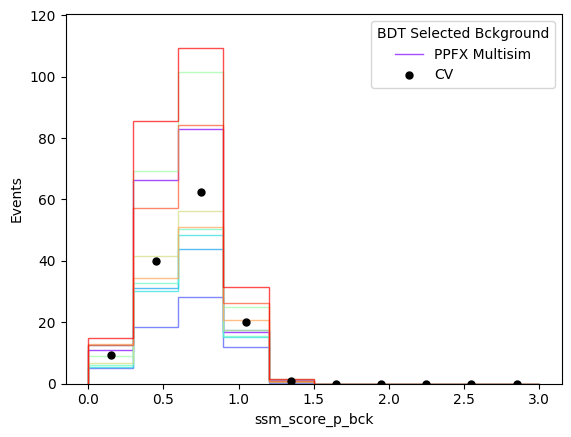

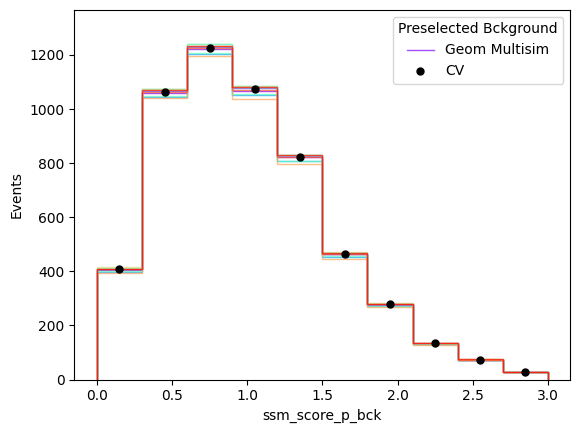

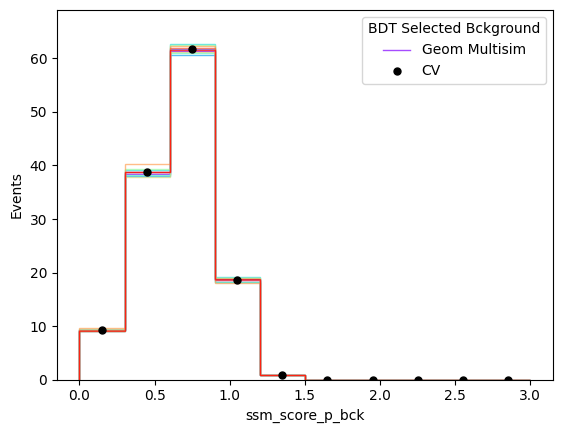

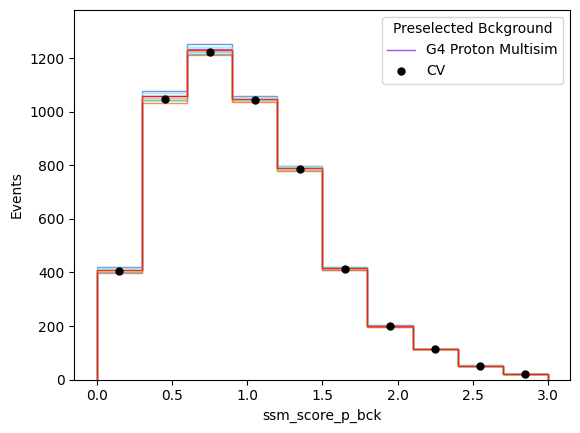

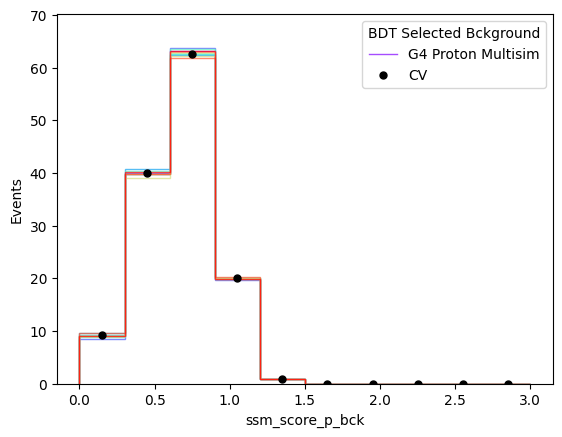

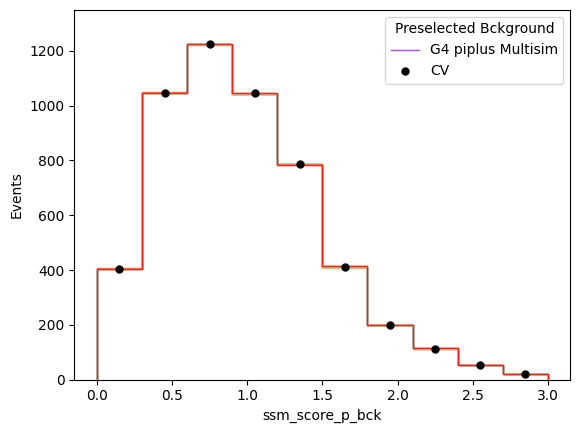

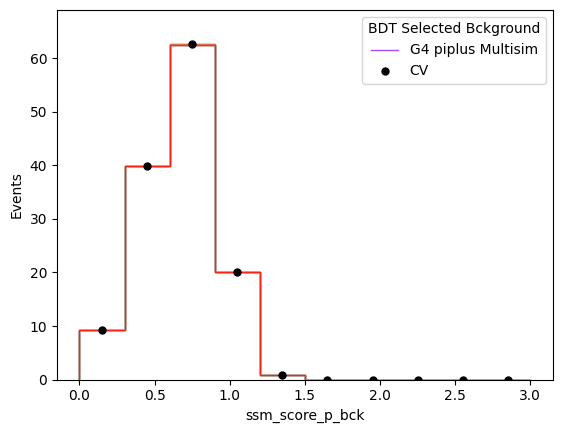

In [105]:
var = 'ssm_score_p_bck'
xmin = 0
xmax = 3
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

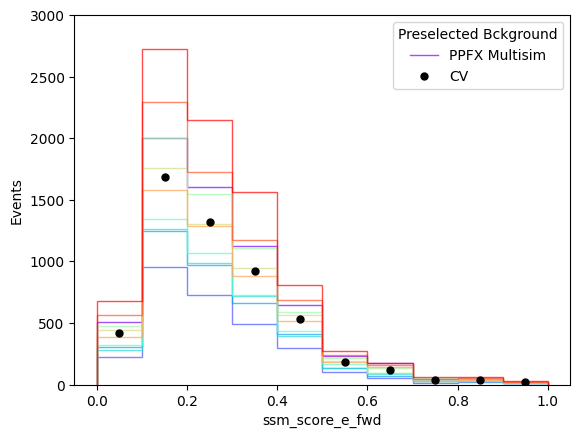

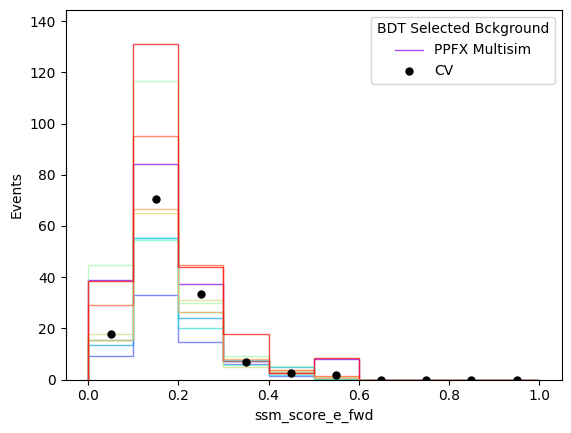

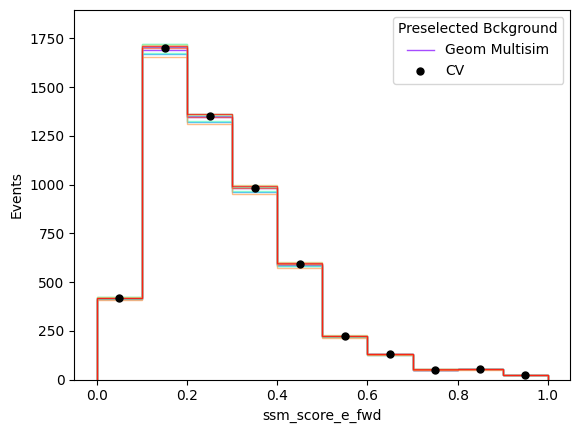

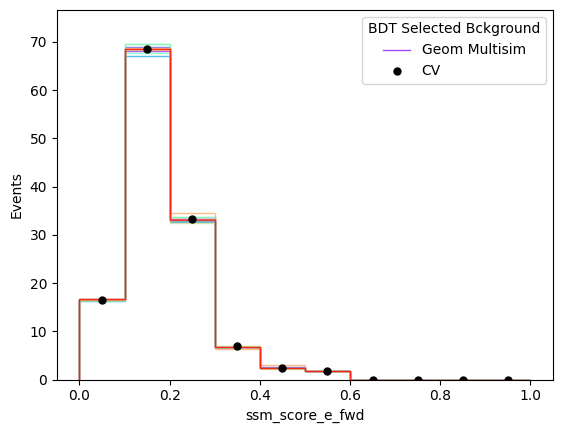

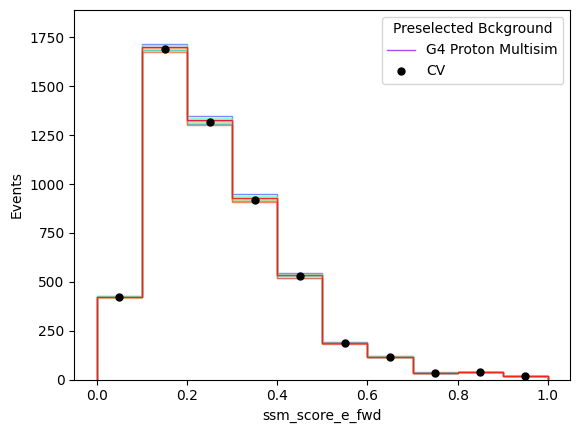

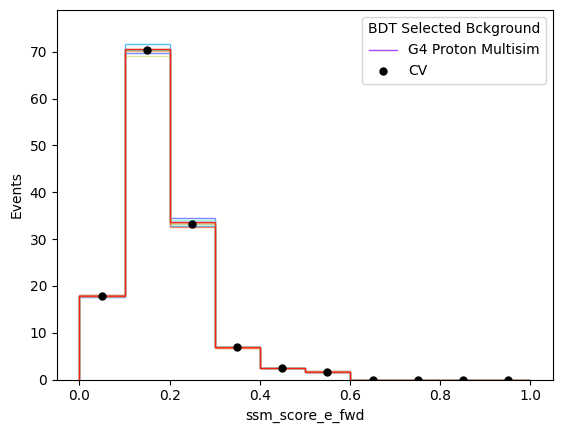

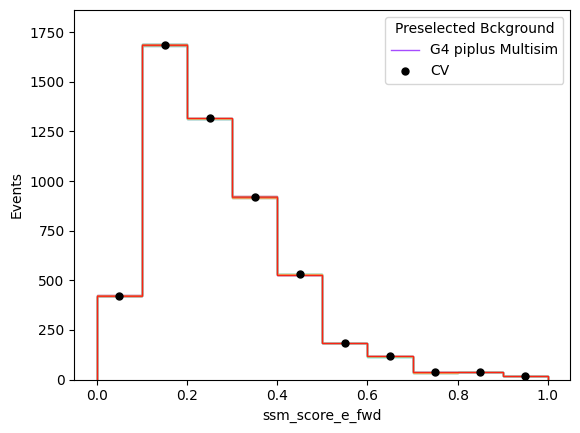

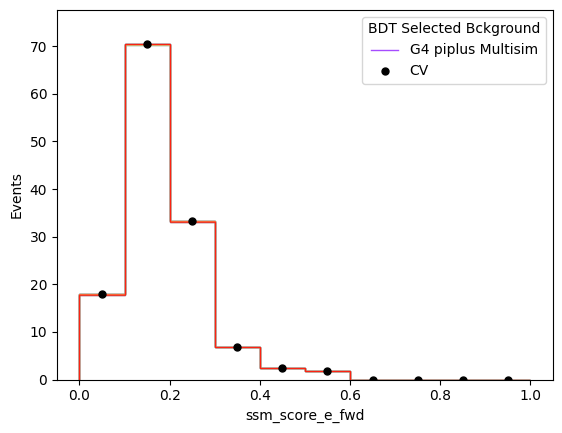

In [106]:
var = 'ssm_score_e_fwd'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

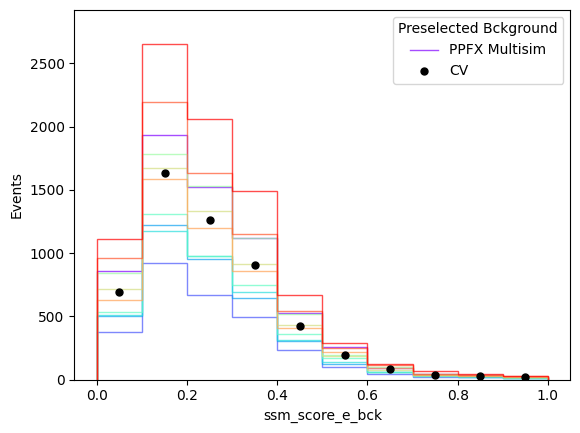

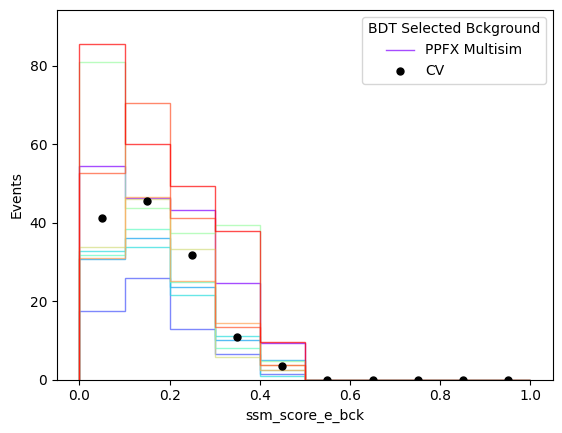

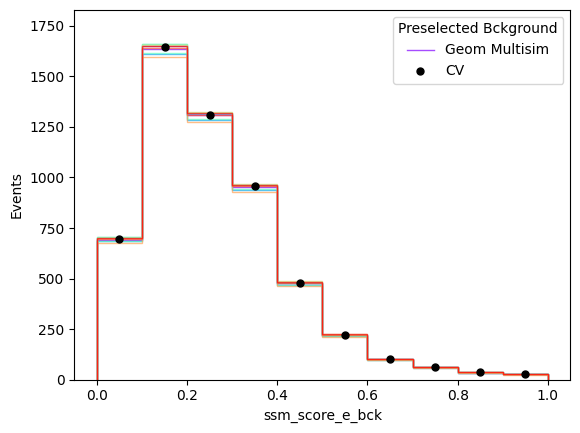

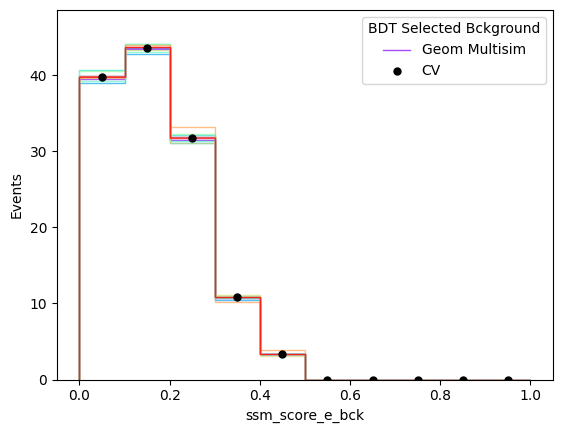

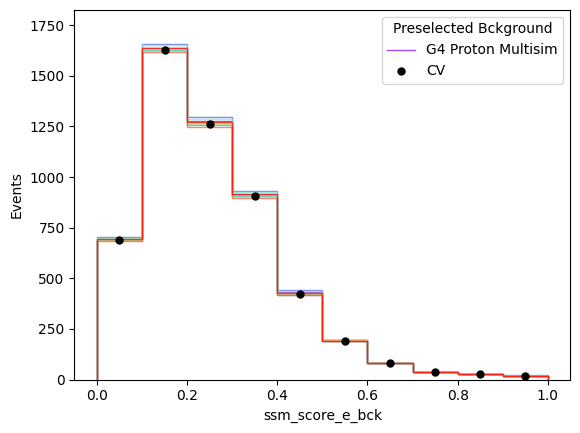

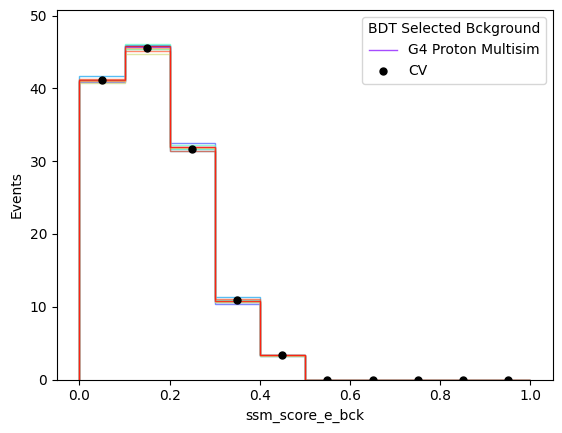

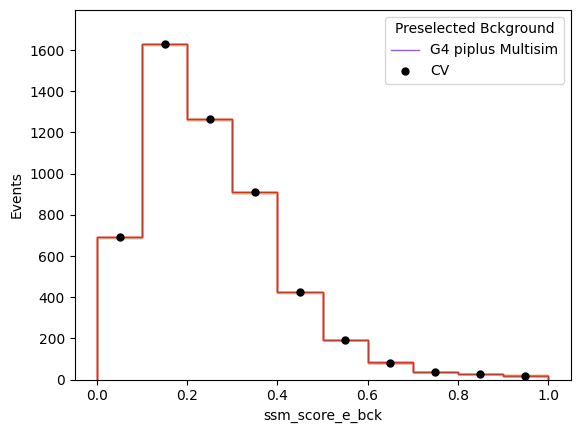

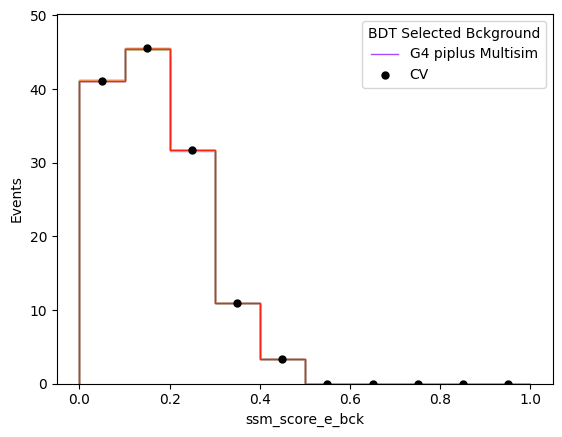

In [107]:
var = 'ssm_score_e_bck'
xmin = 0
xmax = 1
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

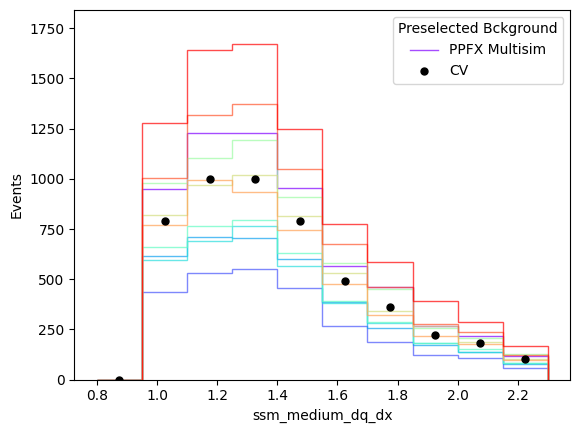

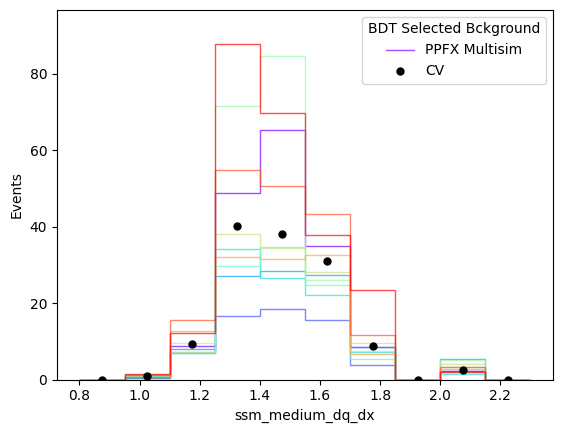

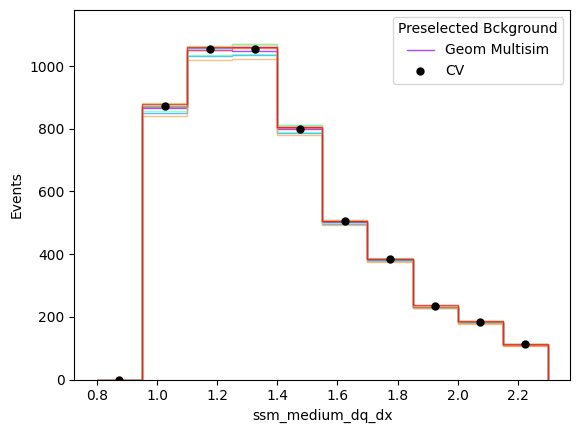

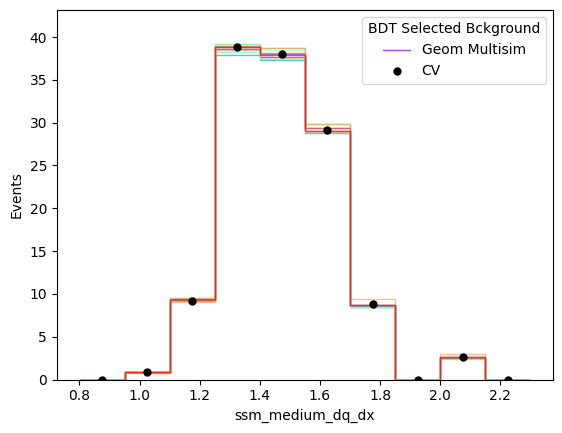

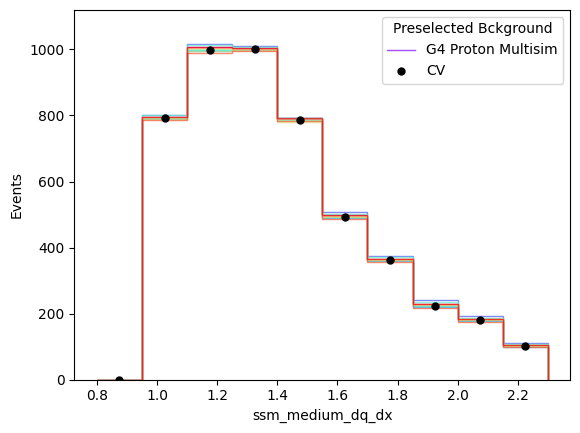

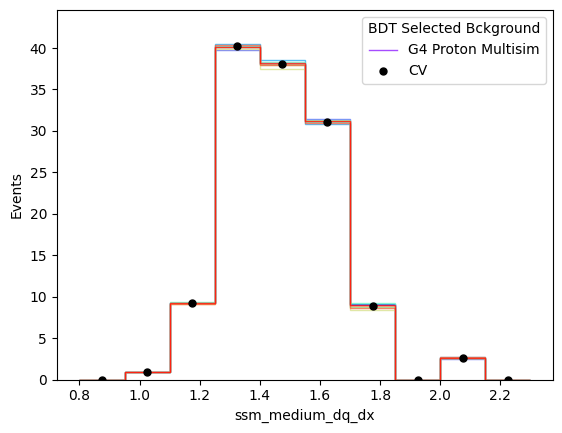

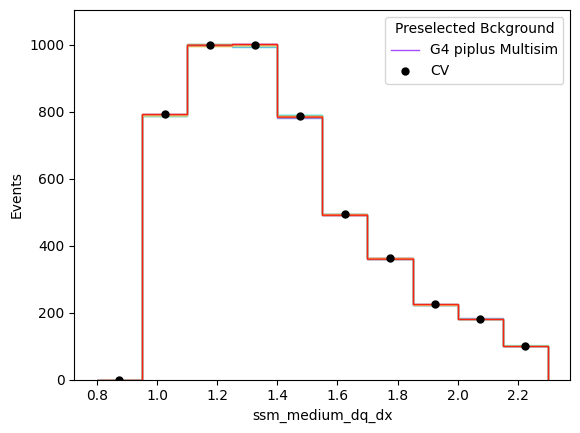

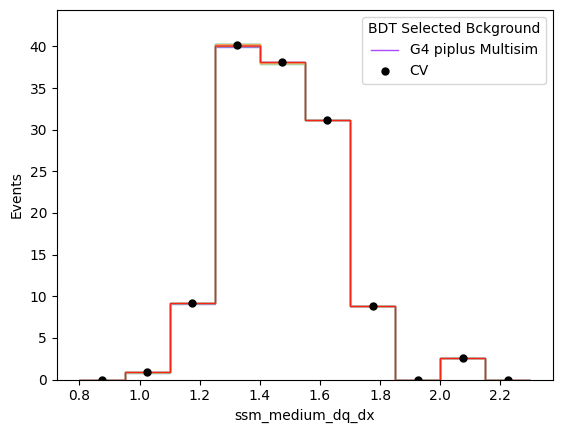

In [108]:
var = 'ssm_medium_dq_dx'
xmin = 0.8
xmax = 2.3
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

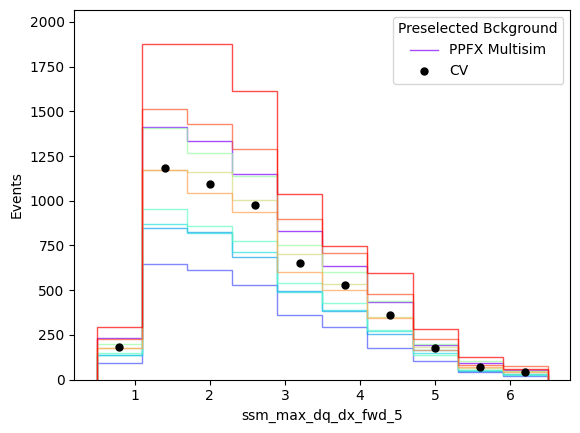

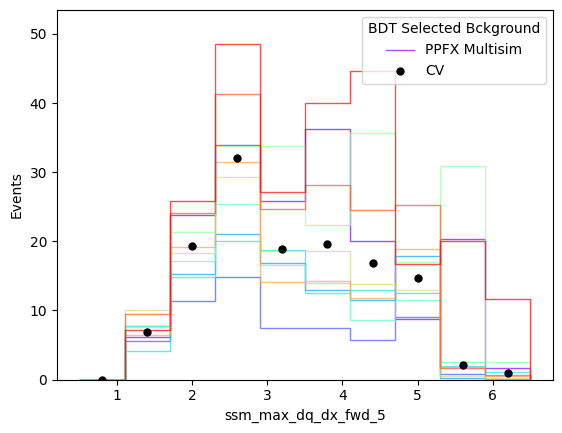

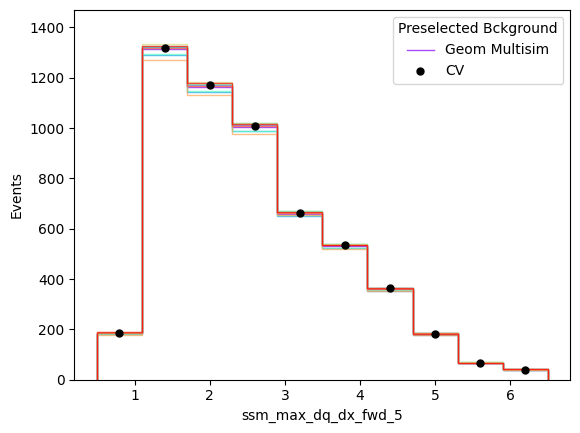

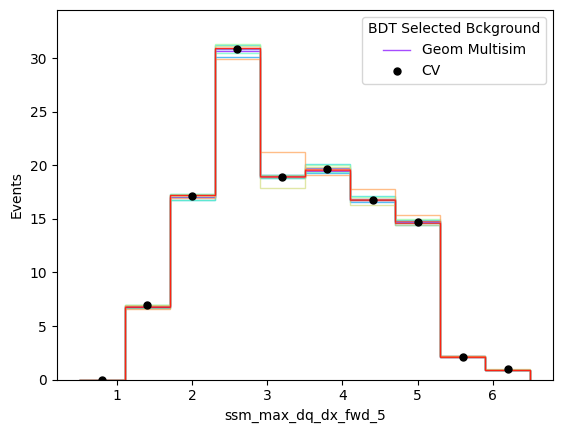

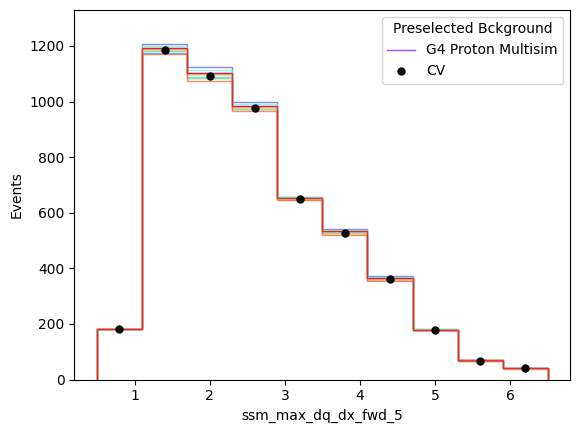

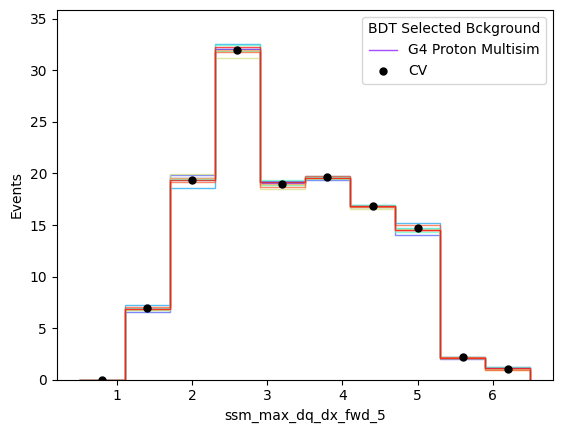

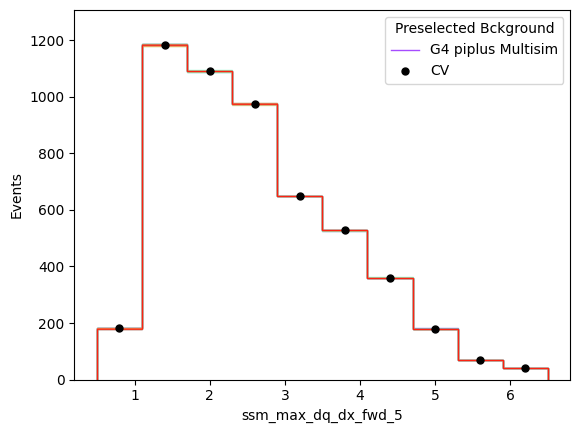

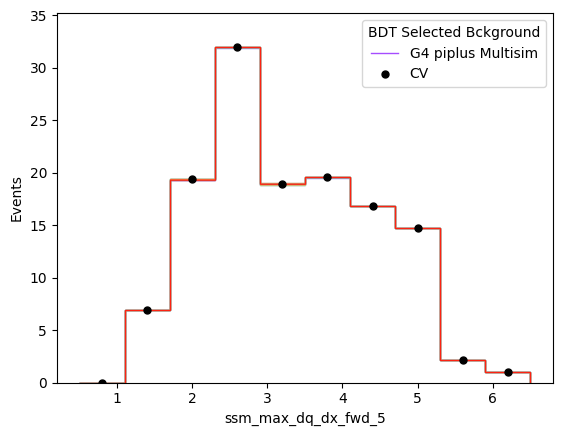

In [109]:
var = 'ssm_max_dq_dx_fwd_5'
xmin = 0.5
xmax = 6.5
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

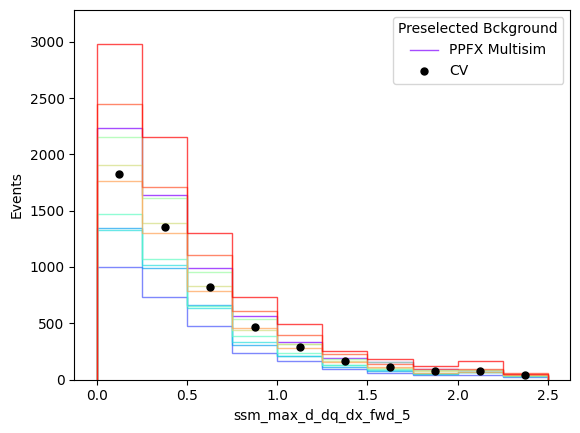

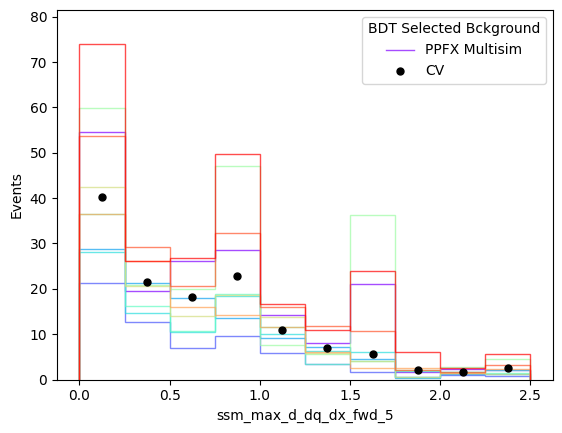

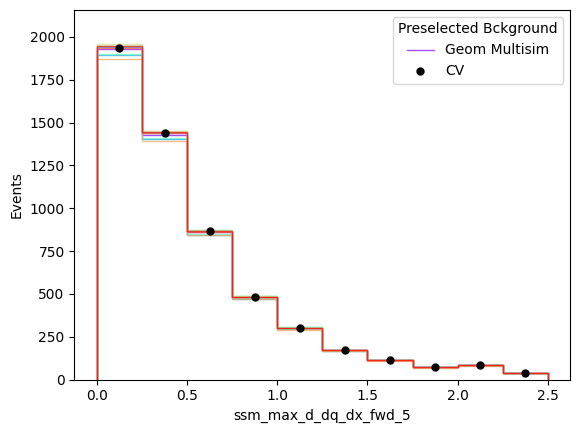

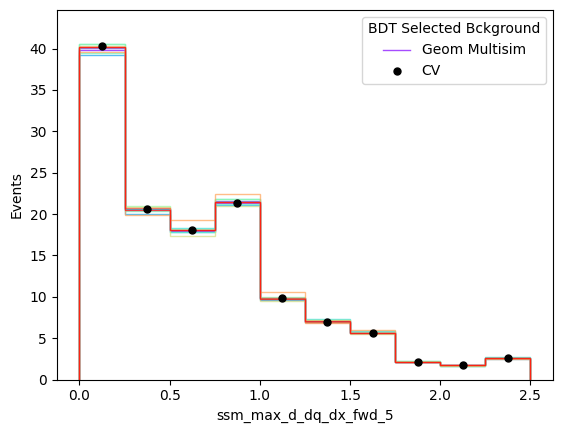

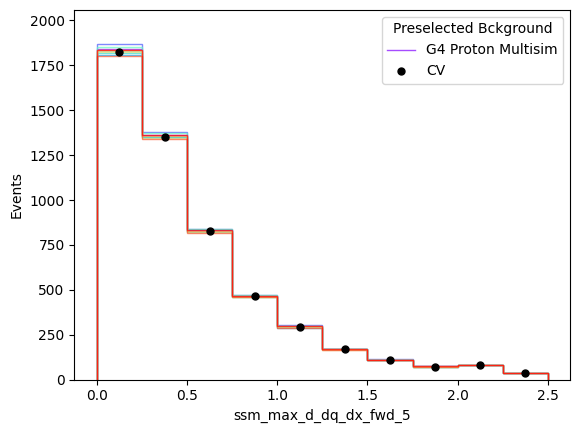

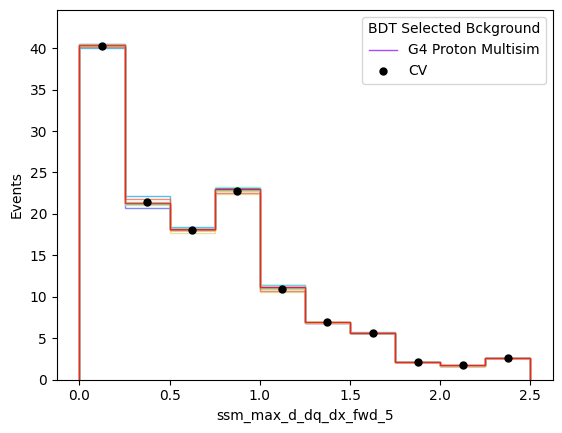

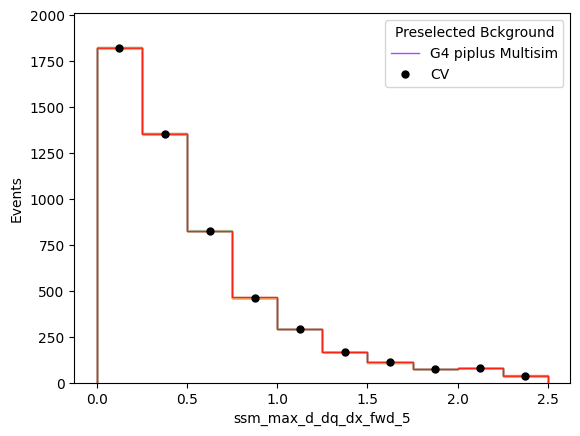

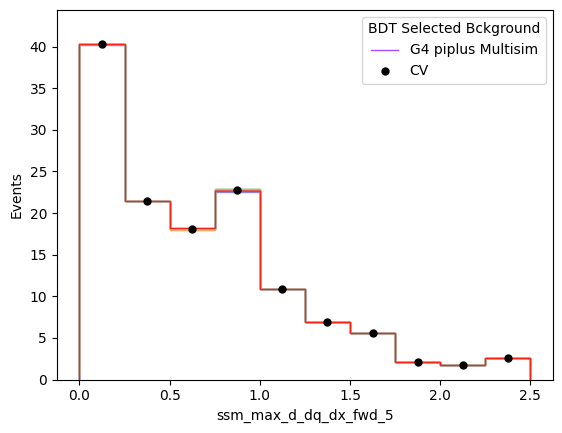

In [110]:
var = 'ssm_max_d_dq_dx_fwd_5'
xmin = 0
xmax = 2.5
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

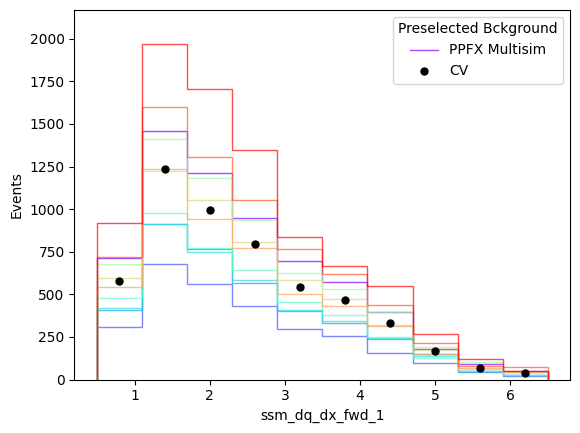

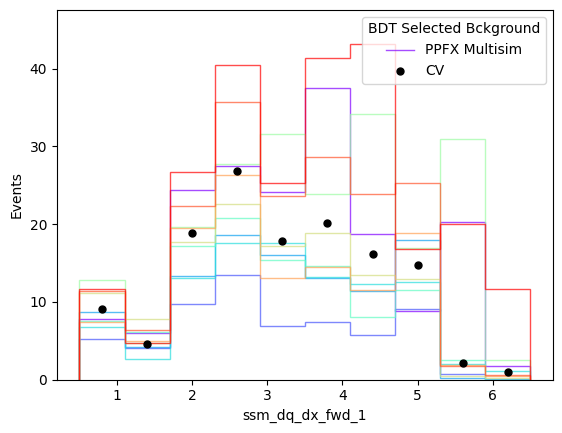

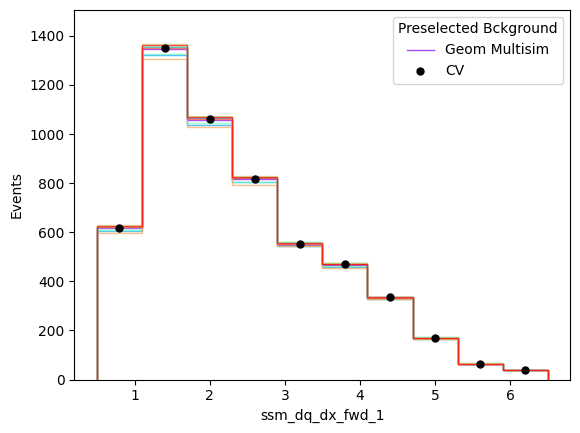

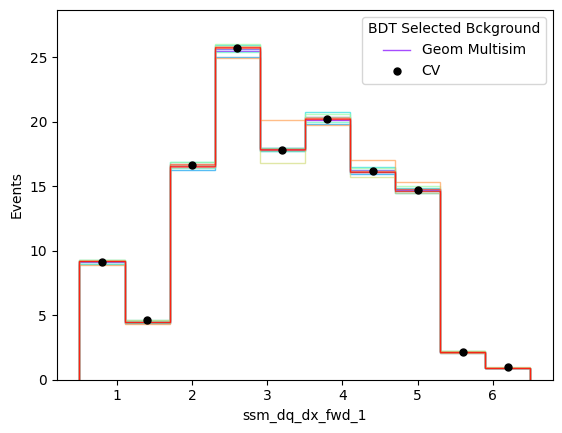

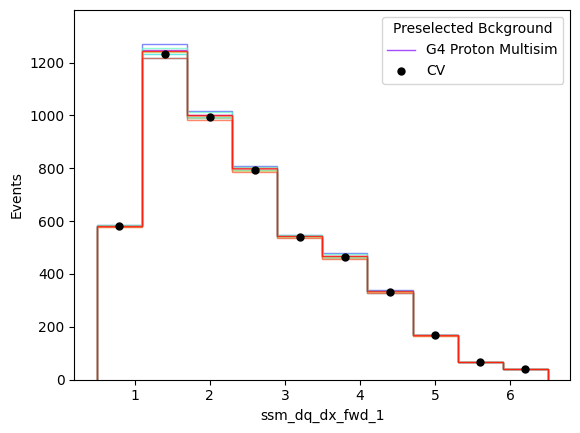

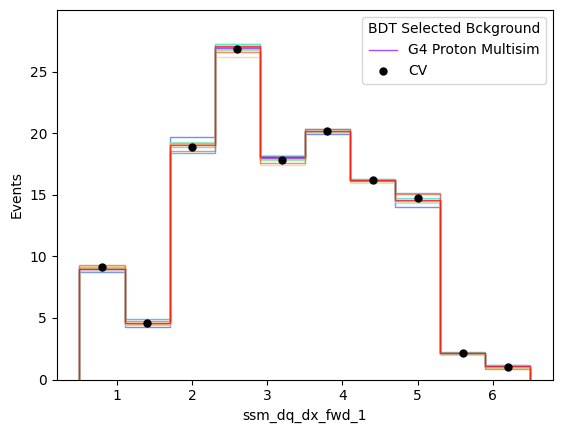

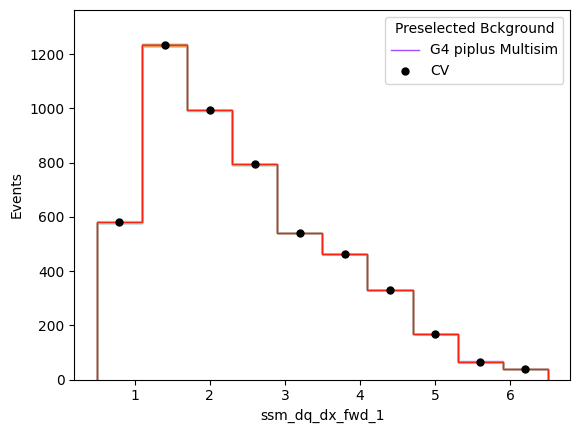

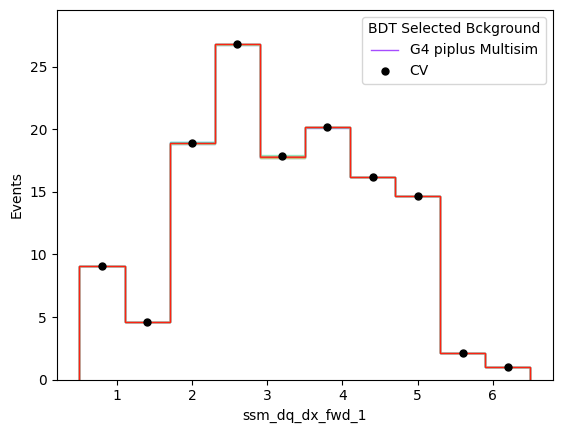

In [111]:
var = 'ssm_dq_dx_fwd_1'
xmin = 0.5
xmax = 6.5
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)

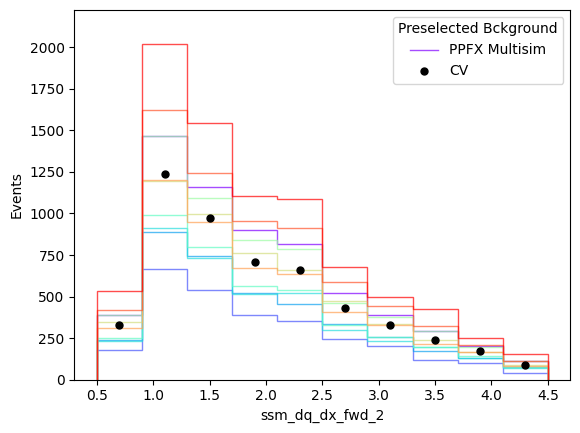

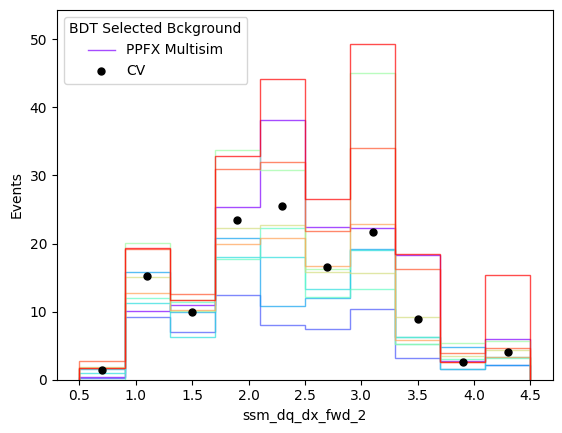

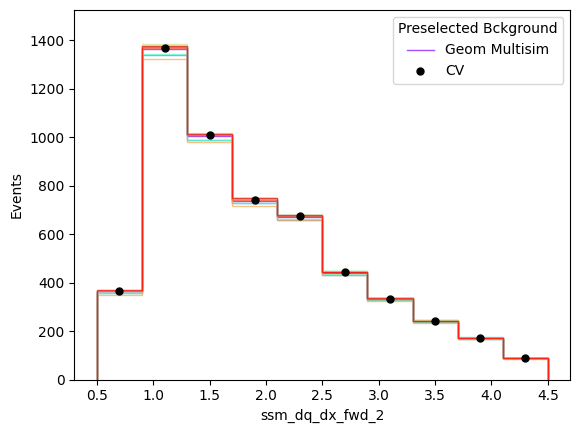

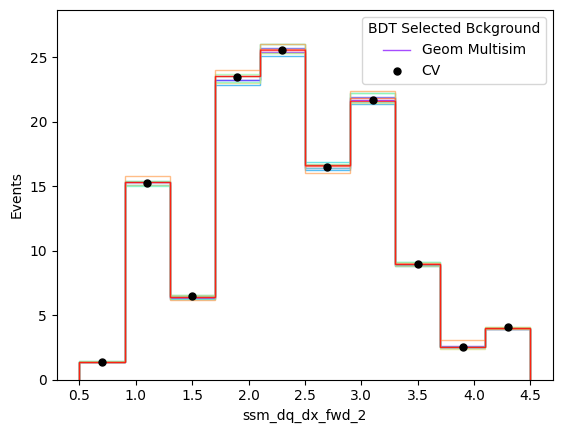

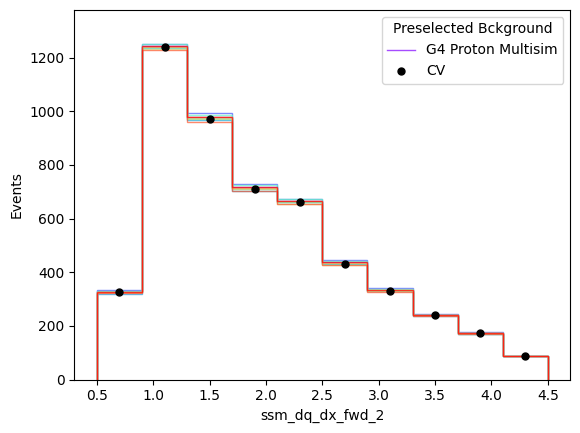

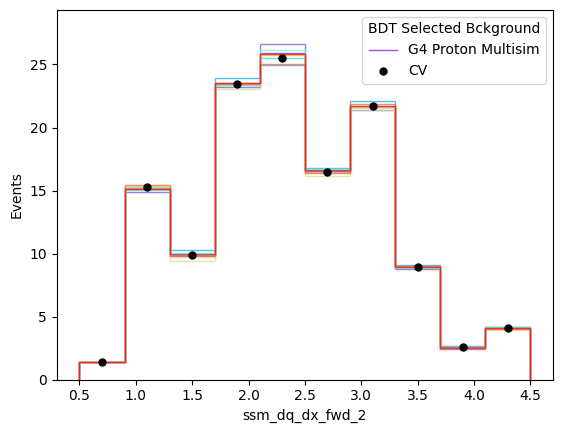

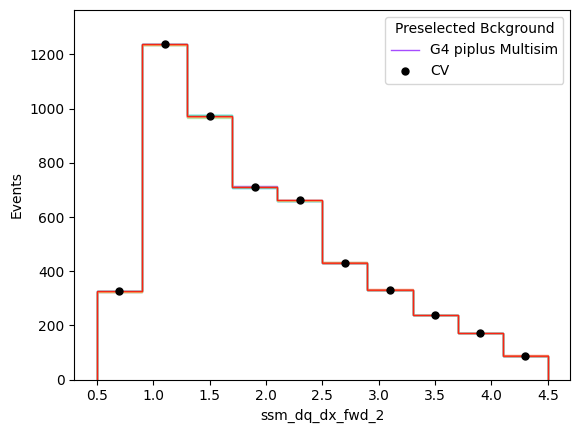

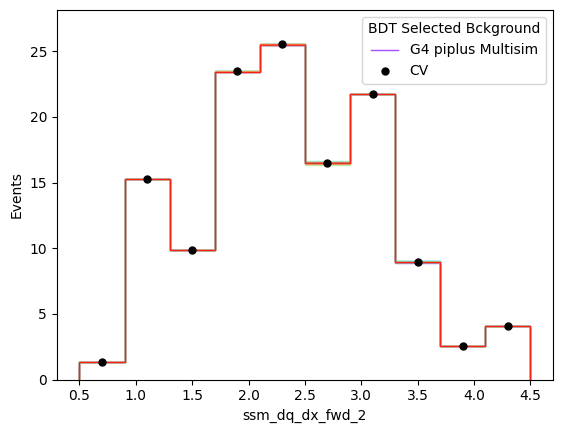

In [114]:
var = 'ssm_dq_dx_fwd_2'
xmin = 0.5
xmax = 4.5
nbins = 10
check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=10,check_n_pip_uni=0)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_geom_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_p_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_p_uni=10)

check_var(var,xmin,xmax,nbins,check_presel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)
check_var(var,xmin,xmax,nbins,check_bdtsel=True,check_n_ppfx_uni=0,check_n_pip_uni=10)